<a href="https://colab.research.google.com/github/mamerokhaya13-afk/Python-pour-la-sant-/blob/main/Modele_BYM2_et_Radon_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Étape 1 : Importer les bibliothèques nécessaires

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import geopandas
import os
import shutil
import scipy.sparse as sp
import libpysal

ModuleNotFoundError: No module named 'libpysal'

In [ ]:
# Mettre à jour numpy et pandas, forçant la réinstallation pour résoudre les conflits avec les paquets système
!pip install numpy pandas --upgrade --force-reinstall

# Installer libpysal
!pip install libpysal

  Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.6-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached pandas-3.0.6-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.8 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
error: uninstall-no-record-file

× Cannot uninstall numpy 1.26.4
╰─> The package's contents are unknown: no R

### Étape 2 : Recharger les données brutes

In [ ]:
# Importation des données
Chemin_cas_du_paludisme_mensuel= '/content/drive/MyDrive/def-Cas de paludisme mensuel 2019 à 2025 vf.csv'
cas_du_palusdisme_mensuel = pd.read_csv(Chemin_cas_du_paludisme_mensuel, encoding='latin-1', header=[1, 2], sep='\t')

# Aplatir les noms de colonnes
# La première colonne spéciale est gérée différemment.
# Les colonnes suivantes sont au format (mois-année, groupe d'âge).
new_columns = []
for col in cas_du_palusdisme_mensuel.columns:
    if isinstance(col, tuple):
        if col[0].strip() == 'Période': # Handle the special first column 'Période' and its sub-header 'ID' or 'District sanitaire/Age'
            if col[1].strip() == 'ID': # The 'ID' column is under 'Période'
                new_columns.append('ID')
            elif col[1].strip() == 'District sanitaire/Age': # The 'District sanitaire/Age' column is also under 'Période'
                new_columns.append('District sanitaire/Age')
            else: # Fallback for other unexpected sub-headers under 'Période'
                new_columns.append(f"{col[0].strip()}_{col[1].strip()}")
        else:
            # For monthly data, combine month-year and age group
            # Replace spaces and special characters in age groups for cleaner names
            level0 = col[0].strip()
            level1 = col[1].strip().replace(' ', '_').replace('>', 'ge').replace('-', '_')
            new_columns.append(f"{level0}_{level1}")
    else:
        new_columns.append(col.strip())

cas_du_palusdisme_mensuel.columns = new_columns

# Y-except block below)
Chemin_temperature = '/content/drive/MyDrive/CSV_temperature_mensuelle_Senegal_2015_2025.csv'
temperature = pd.read_csv(Chemin_temperature, encoding='latin-1')
chemin_fichier_precip_raw = '/content/drive/MyDrive/CSV_precip_mensuelle_Senegal_2015_2025.csv' # Renamed to avoid conflict
precipitation = pd.read_csv(chemin_fichier_precip_raw, encoding='latin-1')
chemin_humidite_du_sol ='/content/drive/MyDrive/Colab Notebooks/Humidite_Sol_Senegal_XY_2015_2025.csv'
humidite_du_sol = pd.read_csv(chemin_humidite_du_sol, encoding='latin-1')

### Étape 3 : Préparer le DataFrame `df_long` (cas de paludisme)

In [ ]:
# Melt the DataFrame to convert from wide to long format
df_long = cas_du_palusdisme_mensuel.melt(
    id_vars=['Unnamed: 0_level_0_ID', 'District sanitaire/Age'],
    var_name='Date_AgeGroup',
    value_name='Nombre_de_cas'
)

# Split the 'Date_AgeGroup' column to extract Date and Age_Group
# Use split('_', n=1) to ensure only the first underscore separates date from age group
df_long[['Date', 'Age_Group']] = df_long['Date_AgeGroup'].str.split('_', n=1, expand=True)

# Convert 'Date' to datetime objects. Handle month name abbreviations if necessary.
# For example, 'janv-19' needs to be converted to '01-2019'
# We'll need a mapping for French month abbreviations to numbers, with keys normalized to match `unicodedata` output
month_map = {
    'janv': '01', 'fevr': '02', 'mars': '03', 'avr': '04', 'mai': '05', 'juin': '06',
    'juil': '07', 'aout': '08', 'sept': '09', 'oct': '10', 'nov': '11', 'dec': '12'
}

# Apply normalization to the month string before lookup to handle potential encoding differences
df_long['Date'] = df_long['Date'].apply(lambda x: f"{month_map[unicodedata.normalize('NFKD', x.split('-')[0]).encode('ascii', 'ignore').decode('utf-8')]}-{x.split('-')[1]}")
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%m-%y')

# Drop the original 'Date_AgeGroup' column as it's no longer needed
df_long = df_long.drop(columns=['Date_AgeGroup'])

# Convertir 'Nombre_de_cas' en type numérique, en forçant les erreurs à NaN
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

# Renommer la colonne 'District sanitaire/Age' en 'District sanitaire'
df_long = df_long.rename(columns={'District sanitaire/Age': 'District sanitaire'})

# Imputer les valeurs manquantes de 'Nombre_de_cas' par la médiane par 'District sanitaire'
df_long['Nombre_de_cas'] = df_long.groupby('District sanitaire')['Nombre_de_cas'].transform(lambda x: x.fillna(x.median()))

# Normaliser la colonne 'District sanitaire' pour la fusion
def normalize_district_name(name):
    if isinstance(name, str):
        return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8').lower().replace(' ', '_').replace('-', '_')
    return name

df_long['District_Key'] = df_long['District sanitaire'].apply(normalize_district_name)

print("df_long préparé:")
display(df_long.head())

df_long préparé:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling


### Étape 4 : Préparer le GeoDataFrame `gdf`

In [ ]:
drive_dir = '/content/drive/MyDrive'
shapefile_base_name = 'Limite_DS_20'
drive_shapefile_path = os.path.join(drive_dir, f'{shapefile_base_name}.shp')

local_temp_dir = '/tmp/shapefile_data'
os.makedirs(local_temp_dir, exist_ok=True)

copied = []
for f in os.listdir(drive_dir):
    if f.startswith(shapefile_base_name):
        shutil.copy(os.path.join(drive_dir, f), os.path.join(local_temp_dir, f))
        copied.append(f)

local_shapefile_path = os.path.join(local_temp_dir, f'{shapefile_base_name}.shp')
gdf = geopandas.read_file(local_shapefile_path)

def normalize_district_name(name):
    if isinstance(name, str):
        normalized = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
        return normalized.lower().replace(' ', '_').replace('-', '_')
    return name

if 'NOM_COMMUNE' in gdf.columns:
    gdf['district_key'] = gdf['NOM_COMMUNE'].apply(normalize_district_name)
elif 'NAME' in gdf.columns:
    gdf['district_key'] = gdf['NAME'].apply(normalize_district_name)
else:
    raise KeyError("Colonne de nom de district non trouvée dans gdf.")

# Mapping manuel complet des districts (recréé tel qu'identifié et corrigé précédemment)
mapping_districts_final = {
    'BAKEL': 'bakel',
    'BAMBEY': 'bambey',
    'BIGNONA': 'bignona',
    'BIRK': 'birkelane',
    'BOUNKILING': 'bounkiling',
    'COKI': 'coki',
    'D M': 'darou_mousty',
    'DAGANA': 'dagana',
    'DAHRA': 'dahra',
    'DIAKH': 'diakhao',
    'DIANKHEMAKHAN': 'diankhe_makhan',
    'DIOF': 'dioffior',
    'DIOULOULOU': 'diouloulou',
    'DIOUR': 'diourbel',
    'FK': None,
    'FOUND': 'foundiougne',
    'GEO': None,
    'GOSSAS': 'gossas',
    'GOSSASS': 'gossas', # Correction for 'gossass' in gdf to map to 'gossas' in df_long
    'GOUDIRY': 'goudiry',
    'GOUDOMP': 'goudomp',
    'JOAL': 'joal_fadiouth',
    'KAFFRINE': 'kaffrine',
    'KANEL': 'kanel',
    'KEBEMER': 'kebemer',
    'KEDOUGOU': 'kedougou',
    'KHO': 'khombole',
    'KL': 'kaolack',
    'KMS': 'keur_momar_sarr',
    'KODIRA': 'kidira',
    'KOLDA': 'kolda',
    'KOUMPENTOUM': 'koumpentoum',
    'KOUNGUEUL': 'koungheul',
    'LINGUERE': 'linguiere',
    'LOUGA': 'louga',
    'M H': 'malem_hodar',
    'MALEM_HODDAR': 'malem_hodar', # Correction for 'malem_hoddar' in gdf to map to 'malem_hodar' in df_long
    'MAKACOULIBANTANG': 'makacolibantang',
    'MATAM': 'matam',
    'MBACKE': 'mbacke',
    'MBOUR': 'mbour',
    'MEDINA YORO FOULAH': 'medine_yoro_foulah',
    'MEKHE': 'mekhe',
    'NDOFFANE': 'ndoffane',
    'NIA': 'niakhar',
    'NIORO': 'nioro',
    'NIORO_DU_RIP': 'nioro', # Correction for 'nioro_du_rip' in gdf to map to 'nioro' in df_long
    'NONE': None,
    'OUSSOUYE': 'oussouye',
    'PASSY': 'passy',
    'PETE': 'pete',
    'PODOR': 'podor',
    'POP': 'popenguine',
    'POUT': 'pout',
    'RANEROU': 'ranerou',
    'RICHARD TOLL': 'richard_toll',
    'SAINT LOUIS': 'saint_louis',
    'SAKAL': 'sakal',
    'SALEMATA': 'salemata',
    'SARAYA': 'saraya',
    'SEDHIOU': 'sedhiou',
    'SOKONE': 'sokone',
    'TAMBA': 'tambacounda',
    'TH ESS': 'thionck_essyl',
    'THIADIAYE': 'thiadiaye',
    'THIES': 'thies',
    'THILOGNE': 'thilogne',
    'TIVAOUANE': 'tivaouane',
    'TOUBA': 'touba',
    'VELINGARA': 'velingara',
    'ZIGUINCHOR': 'ziguinchor',
    'DAKAR CENTRE': 'dakar_centre',
    'DAKAR NORD': 'dakar_nord',
    'DAKAR OUEST': 'dakar_ouest',
    'DAKAR SUD': 'dakar_sud',
    'GUEDIAWAYE': 'guediawaye',
    'KEUR MASSAR': 'keur_massar',
    'MBAO': 'mbao',
    'PIKINE': 'pikine',
    'RUFISQUE': 'rufisque',
    'SANGALKAM': 'sangalkam',
    'YEUMBEUL': 'yeumbeul',
    'FATICK': 'fatick',
    'DIAMNIADIO': 'diamniadio'
}

gdf['district_key'] = gdf['district_key'].apply(lambda x: mapping_districts_final.get(str(x).upper(), x) if pd.notna(x) else x)

# Nettoyer gdf des clés de district non valides
gdf_cleaned = gdf.dropna(subset=['district_key'])
gdf = gdf_cleaned.copy()

print("gdf préparé:")
display(gdf.head())

gdf préparé:


,NAME,ISO_CTRY,Distr,Compsurvei,Vacc_janvi,SRNN_Jan_2,SMNNFEV25,VACCFEV25,SURVFEV25,INCIDENCE_,...,Incpalu19,Incpalu_20,Incpalu22,Incpalu23,Incpalu24,CompDST126,Super,SUPERFI_2,geometry,district_key
0,ZIGUINCHOR,SN,Ziguinchor,64.9,42.5,18.6,0.0,0.0,0.0,12.8,...,6.5,0.0,5.0,6.0,13.0,81.1,1.136258e+09,1136,"POLYGON ((395072 1395915.5, 395068.312 1395814...",ziguinchor
1,OUSSOUYE,SN,Oussouye,22.8,100.0,100.0,0.0,0.0,0.0,4.2,...,2.3,0.0,3.0,5.0,5.0,100.0,8.768150e+08,877,"POLYGON ((334747.094 1395557.75, 334362.999 13...",oussouye
2,BIGNONA,SN,Bignona,98.1,92.3,89.7,0.0,0.0,0.0,5.5,...,4.9,0.0,3.0,2.0,6.0,96.9,2.537476e+09,2537,"POLYGON ((403136.689 1455568.25, 403122.687 14...",bignona
3,DIOULOULOU,SN,Diouloulou,100.0,87.0,78.3,0.0,0.0,0.0,12.7,...,4.8,0.0,9.0,10.0,13.0,95.8,1.892995e+09,1893,"POLYGON ((317469.5 1456367.375, 317972.813 145...",diouloulou
4,THIONCK-ESSYL,SN,TH-Ess,60.9,12.5,31.3,0.0,0.0,0.0,4.5,...,2.5,0.0,4.0,5.0,5.0,64.6,9.081884e+08,908,"POLYGON ((352482.406 1424738.124, 352475.406 1...",thionck_essyl


### Étape 5 : Fusionner `df_long` et `gdf`

In [ ]:
# Créer un ensemble des districts valides de gdf pour la fusion
valid_gdf_districts = set(gdf['district_key'].unique())

# Filtrer df_long pour ne conserver que les districts qui ont une correspondance dans gdf
df_long_filtered = df_long[df_long['District_Key'].isin(valid_gdf_districts)].copy()

# Mettre à jour df_long avec la version filtrée
df_long = df_long_filtered.copy()

# Tenter à nouveau la fusion après le filtrage
gdf_for_merge = gdf[['district_key', 'geometry']]

df_merged = pd.merge(
    df_long,
    gdf_for_merge,
    left_on='District_Key',
    right_on='district_key',
    how='left'
)

# Retirer la colonne `district_key` redondante après la fusion
df_merged = df_merged.drop(columns='district_key')

print("df_merged après fusion avec gdf:")
display(df_merged.head())

NameError: name 'df_long' is not defined

### Étape 6 : Fusion des données environnementales

In [ ]:
# Préparation et fusion de la température
if 'date' in temperature.columns:
    temperature['Date'] = pd.to_datetime(temperature['date'])
    temperature = temperature.drop(columns=['date'])
elif 'Date' in temperature.columns:
    if not pd.api.types.is_datetime64_any_dtype(temperature['Date']):
        temperature['Date'] = pd.to_datetime(temperature['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'temperature'.")

df_merged = pd.merge(
    df_merged,
    temperature[['Date', 'temperature_celsius']],
    on='Date',
    how='left'
)

# Préparation et fusion de la précipitation
if 'date' in precipitation.columns:
    precipitation['Date'] = pd.to_datetime(precipitation['date'])
    precipitation = precipitation.drop(columns=['date'])
elif 'Date' in precipitation.columns:
    if not pd.api.types.is_datetime64_any_dtype(precipitation['Date']):
        precipitation['Date'] = pd.to_datetime(precipitation['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'precipitation'.")

df_merged = pd.merge(
    df_merged,
    precipitation[['Date', 'precipitation_mm']],
    on='Date',
    how='left'
)

# Préparation et fusion de l'humidité du sol
# Assurez-vous que 'Date' est au format datetime avant de grouper
humidite_du_sol['Date'] = pd.to_datetime(humidite_du_sol['date'])
humidite_du_sol_aggregated = humidite_du_sol.groupby('Date')['ssm'].mean().reset_index()
humidite_du_sol_to_merge = humidite_du_sol_aggregated

df_merged = pd.merge(
    df_merged,
    humidite_du_sol_to_merge[['Date', 'ssm']],
    on='Date',
    how='left'
)

# Consolidation des colonnes redondantes (générées par des merges multiples si les noms sont similaires)
# On vérifie s'il y a des colonnes dupliquées avec suffixes _x, _y
for col_name in ['temperature_celsius', 'precipitation_mm', 'ssm']:
    if f'{col_name}_x' in df_merged.columns and f'{col_name}_y' in df_merged.columns:
        df_merged[col_name] = df_merged[f'{col_name}_x'].fillna(df_merged[f'{col_name}_y'])
        df_merged = df_merged.drop(columns=[f'{col_name}_x', f'{col_name}_y'])
    elif f'{col_name}_x' in df_merged.columns:
        df_merged[col_name] = df_merged[f'{col_name}_x'] # Renomme si seulement _x existe
        df_merged = df_merged.drop(columns=[f'{col_name}_x'])
    elif f'{col_name}_y' in df_merged.columns:
        df_merged[col_name] = df_merged[f'{col_name}_y'] # Renomme si seulement _y existe
        df_merged = df_merged.drop(columns=[f'{col_name}_y'])

print("df_merged après fusion avec les données environnementales:")
display(df_merged.head())

df_merged après fusion avec les données environnementales:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,NaN
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,NaN
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,NaN
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,NaN
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,NaN


### Étape 7 : Imputation des valeurs manquantes et finalisation de `df_bym2`

In [ ]:
# Créer une colonne 'month' pour l'imputation
df_merged['month'] = df_merged['Date'].dt.month

# Imputation pour 'temperature_celsius'
if 'month' not in temperature.columns:
    temperature['month'] = temperature['Date'].dt.month
monthly_median_temp = temperature.groupby('month')['temperature_celsius'].median()
df_merged['temperature_celsius'] = df_merged['temperature_celsius'].fillna(
    df_merged['month'].map(monthly_median_temp)
)

# Imputation pour 'ssm'
if 'month' not in humidite_du_sol_to_merge.columns:
    humidite_du_sol_to_merge['month'] = humidite_du_sol_to_merge['Date'].dt.month
monthly_median_ssm = humidite_du_sol_to_merge.groupby('month')['ssm'].median()
df_merged['ssm'] = df_merged['ssm'].fillna(
    df_merged['month'].map(monthly_median_ssm)
)

# Imputation finale pour 'Nombre_de_cas' (stratégie séquentielle)
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'Age_Group', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))
df_merged['Nombre_de_cas'] = df_merged.groupby('month')['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))
df_merged['Nombre_de_cas'] = df_merged['Nombre_de_cas'].fillna(df_merged['Nombre_de_cas'].median())

# Supprimer la colonne temporaire 'month'
df_merged = df_merged.drop(columns=['month'])

# Préparer df_bym2 final
df_bym2 = df_merged[[
    'District_Key',
    'Date',
    'Age_Group',
    'Nombre_de_cas',
    'temperature_celsius',
    'precipitation_mm',
    'ssm'
]].copy()

df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].astype(str)
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].str.replace(r'[^0-9]', '', regex=True)
df_bym2['Nombre_de_cas'] = pd.to_numeric(df_bym2['Nombre_de_cas'], errors='coerce')
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].fillna(0).astype(int)
df_bym2['District_Key'] = df_bym2['District_Key'].astype(str)

print("df_bym2 final prêt:")
display(df_bym2.head())
df_bym2.info()

df_bym2 final prêt:


,District_Key,Date,Age_Group,Nombre_de_cas,temperature_celsius,precipitation_mm,ssm
0,bakel,2019-01-01,0_4_ans,140,24.961213,0.380105,2.676384
1,bambey,2019-01-01,0_4_ans,70,24.961213,0.380105,2.676384
2,bignona,2019-01-01,0_4_ans,50,24.961213,0.380105,2.676384
3,birkelane,2019-01-01,0_4_ans,20,24.961213,0.380105,2.676384
4,bounkiling,2019-01-01,0_4_ans,200,24.961213,0.380105,2.676384


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13104 entries, 0 to 13103
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   District_Key         13104 non-null  object        
 1   Date                 13104 non-null  datetime64[ns]
 2   Age_Group            13104 non-null  object        
 3   Nombre_de_cas        13104 non-null  int64         
 4   temperature_celsius  13104 non-null  float64       
 5   precipitation_mm     13104 non-null  float64       
 6   ssm                  13104 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 716.8+ KB


### Étape 8 : Vérification et préparation des indices spatiaux pour le modèle BYM2

In [ ]:
# Filtrer gdf pour inclure uniquement les districts présents dans df_bym2
# Ceci est fait avant de créer les indices pour s'assurer que N_districts correspond à la matrice d'adjacence
gdf_filtered_for_bym2 = gdf[gdf['district_key'].isin(df_bym2['District_Key'].unique())].copy()

# Exclure de df_bym2 les districts qui n'ont pas de correspondance dans gdf_filtered_for_bym2
# C'est la correction clé pour aligner les dimensions
df_bym2 = df_bym2[df_bym2['District_Key'].isin(gdf_filtered_for_bym2['district_key'].unique())].copy()

# Créer des indices numériques pour les districts à partir du df_bym2 filtré
unique_districts = df_bym2['District_Key'].unique()
district_to_idx = {district: i for i, district in enumerate(unique_districts)}
df_bym2['District_idx'] = df_bym2['District_Key'].map(district_to_idx)
N_districts = len(unique_districts)

# Créer des indices numériques pour les groupes d'âge
unique_age_groups = df_bym2['Age_Group'].unique()
age_group_to_idx = {age: i for i, age in enumerate(unique_age_groups)}
df_bym2['Age_idx'] = df_bym2['Age_Group'].map(age_group_to_idx)
N_age_groups = len(unique_age_groups)

# Trier gdf_filtered_for_bym2 par district_key pour correspondre à l'ordre de unique_districts (et donc district_to_idx)
gdf_filtered_for_bym2['district_order'] = gdf_filtered_for_bym2['district_key'].map(district_to_idx)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.sort_values('district_order').reset_index(drop=True)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.drop(columns=['district_order'])

# Recréer la matrice d'adjacence en utilisant le GeoDataFrame filtré et trié
weights = libpysal.weights.Queen.from_dataframe(gdf_filtered_for_bym2, silence_warnings=True)
adj_matrix_dense = weights.sparse.toarray()

# Maintenant, créer W_sparse à partir de cette matrice d'adjacence correcte
W_sparse = sp.csr_matrix(adj_matrix_dense)
W_sparse.eliminate_zeros() # S'assurer qu'il n'y a pas de zéros explicites

# Extraire les données nécessaires pour le modèle
y_obs = df_bym2['Nombre_de_cas'].values
district_idx_obs = df_bym2['District_idx'].values
age_idx_obs = df_bym2['Age_idx'].values
temp_obs = df_bym2['temperature_celsius'].values
precip_obs = df_bym2['precipitation_mm'].values
ssm_obs = df_bym2['ssm'].values

print("df_bym2 et W_sparse prêts pour le modèle BYM2.")
display(df_bym2.head())

/tmp/ipykernel_63138/2861279908.py:27: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  weights = libpysal.weights.Queen.from_dataframe(gdf_filtered_for_bym2, silence_warnings=True)


df_bym2 et W_sparse prêts pour le modèle BYM2.


,District_Key,Date,Age_Group,Nombre_de_cas,temperature_celsius,precipitation_mm,ssm,District_idx,Age_idx
0,bakel,2019-01-01,0_4_ans,140,24.961213,0.380105,2.676384,0,0
1,bambey,2019-01-01,0_4_ans,70,24.961213,0.380105,2.676384,1,0
2,bignona,2019-01-01,0_4_ans,50,24.961213,0.380105,2.676384,2,0
3,birkelane,2019-01-01,0_4_ans,20,24.961213,0.380105,2.676384,3,0
4,bounkiling,2019-01-01,0_4_ans,200,24.961213,0.380105,2.676384,4,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import geopandas
import os
import shutil
import scipy.sparse as sp
import libpysal

### Rechargement des données brutes

In [ ]:
# Importation des données
Chemin_cas_du_paludisme_mensuel= '/content/drive/MyDrive/def-Cas de paludisme mensuel 2019 à 2025 vf.csv'
cas_du_palusdisme_mensuel = pd.read_csv(Chemin_cas_du_paludisme_mensuel, encoding='latin-1', header=[1, 2], sep='\t')

# Aplatir les noms de colonnes
# La première colonne spéciale est gérée différemment.
# Les colonnes suivantes sont au format (mois-année, groupe d'âge).
new_columns = []
for col in cas_du_palusdisme_mensuel.columns:
    if isinstance(col, tuple):
        if col[0].strip() == 'Période': # Handle the special first column 'Période' and its sub-header 'ID' or 'District sanitaire/Age'
            if col[1].strip() == 'ID': # The 'ID' column is under 'Période'
                new_columns.append('ID')
            elif col[1].strip() == 'District sanitaire/Age': # The 'District sanitaire/Age' column is also under 'Période'
                new_columns.append('District sanitaire/Age')
            else: # Fallback for other unexpected sub-headers under 'Période'
                new_columns.append(f"{col[0].strip()}_{col[1].strip()}")
        else:
            # For monthly data, combine month-year and age group
            # Replace spaces and special characters in age groups for cleaner names
            level0 = col[0].strip()
            level1 = col[1].strip().replace(' ', '_').replace('>', 'ge').replace('-', '_')
            new_columns.append(f"{level0}_{level1}")
    else:
        new_columns.append(col.strip())

cas_du_palusdisme_mensuel.columns = new_columns

# Y-except block below)
Chemin_temperature = '/content/drive/MyDrive/CSV_temperature_mensuelle_Senegal_2015_2025.csv'
temperature = pd.read_csv(Chemin_temperature, encoding='latin-1')
chemin_fichier_precip_raw = '/content/drive/MyDrive/CSV_precip_mensuelle_Senegal_2015_2025.csv' # Renamed to avoid conflict
precipitation = pd.read_csv(chemin_fichier_precip_raw, encoding='latin-1')
chemin_humidite_du_sol ='/content/drive/MyDrive/Colab Notebooks/Humidite_Sol_Senegal_XY_2015_2025.csv'
humidite_du_sol = pd.read_csv(chemin_humidite_du_sol, encoding='latin-1')


### Préparation du DataFrame `df_long` (cas de paludisme)

In [ ]:
# Melt the DataFrame to convert from wide to long format
df_long = cas_du_palusdisme_mensuel.melt(
    id_vars=['Unnamed: 0_level_0_ID', 'District sanitaire/Age'],
    var_name='Date_AgeGroup',
    value_name='Nombre_de_cas'
)

# Split the 'Date_AgeGroup' column to extract Date and Age_Group
# Use split('_', n=1) to ensure only the first underscore separates date from age group
df_long[['Date', 'Age_Group']] = df_long['Date_AgeGroup'].str.split('_', n=1, expand=True)

# Convert 'Date' to datetime objects. Handle month name abbreviations if necessary.
# For example, 'janv-19' needs to be converted to '01-2019'
# We'll need a mapping for French month abbreviations to numbers, with keys normalized to match `unicodedata` output
month_map = {
    'janv': '01', 'fevr': '02', 'mars': '03', 'avr': '04', 'mai': '05', 'juin': '06',
    'juil': '07', 'aout': '08', 'sept': '09', 'oct': '10', 'nov': '11', 'dec': '12'
}

# Apply normalization to the month string before lookup to handle potential encoding differences
df_long['Date'] = df_long['Date'].apply(lambda x: f"{month_map[unicodedata.normalize('NFKD', x.split('-')[0]).encode('ascii', 'ignore').decode('utf-8')]}-{x.split('-')[1]}")
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%m-%y')

# Drop the original 'Date_AgeGroup' column as it's no longer needed
df_long = df_long.drop(columns=['Date_AgeGroup'])

# Convertir 'Nombre_de_cas' en type numérique, en forçant les erreurs à NaN
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

# Renommer la colonne 'District sanitaire/Age' en 'District sanitaire'
df_long = df_long.rename(columns={'District sanitaire/Age': 'District sanitaire'})

# Imputer les valeurs manquantes de 'Nombre_de_cas' par la médiane par 'District sanitaire'
df_long['Nombre_de_cas'] = df_long.groupby('District sanitaire')['Nombre_de_cas'].transform(lambda x: x.fillna(x.median()))

# Normaliser la colonne 'District sanitaire' pour la fusion
def normalize_district_name(name):
    if isinstance(name, str):
        return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8').lower().replace(' ', '_').replace('-', '_')
    return name

df_long['District_Key'] = df_long['District sanitaire'].apply(normalize_district_name)

print("df_long préparé:")
display(df_long.head())


df_long préparé:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling


### Préparation du GeoDataFrame `gdf`

In [ ]:
drive_dir = '/content/drive/MyDrive'
shapefile_base_name = 'Limite_DS_20'
drive_shapefile_path = os.path.join(drive_dir, f'{shapefile_base_name}.shp')

local_temp_dir = '/tmp/shapefile_data'
os.makedirs(local_temp_dir, exist_ok=True)

copied = []
for f in os.listdir(drive_dir):
    if f.startswith(shapefile_base_name):
        shutil.copy(os.path.join(drive_dir, f), os.path.join(local_temp_dir, f))
        copied.append(f)

local_shapefile_path = os.path.join(local_temp_dir, f'{shapefile_base_name}.shp')
gdf = geopandas.read_file(local_shapefile_path)

def normalize_district_name(name):
    if isinstance(name, str):
        normalized = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
        return normalized.lower().replace(' ', '_').replace('-', '_')
    return name

if 'NOM_COMMUNE' in gdf.columns:
    gdf['district_key'] = gdf['NOM_COMMUNE'].apply(normalize_district_name)
elif 'NAME' in gdf.columns:
    gdf['district_key'] = gdf['NAME'].apply(normalize_district_name)
else:
    raise KeyError("Colonne de nom de district non trouvée dans gdf.")

# Mapping manuel complet des districts (recréé tel qu'identifié et corrigé précédemment)
mapping_districts_final = {
    'BAKEL': 'bakel',
    'BAMBEY': 'bambey',
    'BIGNONA': 'bignona',
    'BIRK': 'birkelane',
    'BOUNKILING': 'bounkiling',
    'COKI': 'coki',
    'D M': 'darou_mousty',
    'DAGANA': 'dagana',
    'DAHRA': 'dahra',
    'DIAKH': 'diakhao',
    'DIANKHEMAKHAN': 'diankhe_makhan',
    'DIOF': 'dioffior',
    'DIOULOULOU': 'diouloulou',
    'DIOUR': 'diourbel',
    'FK': None,
    'FOUND': 'foundiougne',
    'GEO': None,
    'GOSSAS': 'gossas',
    'GOSSASS': 'gossas', # Correction for 'gossass' in gdf to map to 'gossas' in df_long
    'GOUDIRY': 'goudiry',
    'GOUDOMP': 'goudomp',
    'JOAL': 'joal_fadiouth',
    'KAFFRINE': 'kaffrine',
    'KANEL': 'kanel',
    'KEBEMER': 'kebemer',
    'KEDOUGOU': 'kedougou',
    'KHO': 'khombole',
    'KL': 'kaolack',
    'KMS': 'keur_momar_sarr',
    'KODIRA': 'kidira',
    'KOLDA': 'kolda',
    'KOUMPENTOUM': 'koumpentoum',
    'KOUNGUEUL': 'koungheul',
    'LINGUERE': 'linguiere',
    'LOUGA': 'louga',
    'M H': 'malem_hodar',
    'MALEM_HODDAR': 'malem_hodar', # Correction for 'malem_hoddar' in gdf to map to 'malem_hodar' in df_long
    'MAKACOULIBANTANG': 'makacolibantang',
    'MATAM': 'matam',
    'MBACKE': 'mbacke',
    'MBOUR': 'mbour',
    'MEDINA YORO FOULAH': 'medine_yoro_foulah',
    'MEKHE': 'mekhe',
    'NDOFFANE': 'ndoffane',
    'NIA': 'niakhar',
    'NIORO': 'nioro',
    'NIORO_DU_RIP': 'nioro', # Correction for 'nioro_du_rip' in gdf to map to 'nioro' in df_long
    'NONE': None,
    'OUSSOUYE': 'oussouye',
    'PASSY': 'passy',
    'PETE': 'pete',
    'PODOR': 'podor',
    'POP': 'popenguine',
    'POUT': 'pout',
    'RANEROU': 'ranerou',
    'RICHARD TOLL': 'richard_toll',
    'SAINT LOUIS': 'saint_louis',
    'SAKAL': 'sakal',
    'SALEMATA': 'salemata',
    'SARAYA': 'saraya',
    'SEDHIOU': 'sedhiou',
    'SOKONE': 'sokone',
    'TAMBA': 'tambacounda',
    'TH ESS': 'thionck_essyl',
    'THIADIAYE': 'thiadiaye',
    'THIES': 'thies',
    'THILOGNE': 'thilogne',
    'TIVAOUANE': 'tivaouane',
    'TOUBA': 'touba',
    'VELINGARA': 'velingara',
    'ZIGUINCHOR': 'ziguinchor',
    'DAKAR CENTRE': 'dakar_centre',
    'DAKAR NORD': 'dakar_nord',
    'DAKAR OUEST': 'dakar_ouest',
    'DAKAR SUD': 'dakar_sud',
    'GUEDIAWAYE': 'guediawaye',
    'KEUR MASSAR': 'keur_massar',
    'MBAO': 'mbao',
    'PIKINE': 'pikine',
    'RUFISQUE': 'rufisque',
    'SANGALKAM': 'sangalkam',
    'YEUMBEUL': 'yeumbeul',
    'FATICK': 'fatick',
    'DIAMNIADIO': 'diamniadio'
}

gdf['district_key'] = gdf['district_key'].apply(lambda x: mapping_districts_final.get(str(x).upper(), x) if pd.notna(x) else x)

# Nettoyer gdf des clés de district non valides
gdf_cleaned = gdf.dropna(subset=['district_key'])
gdf = gdf_cleaned.copy()

print("gdf préparé:")
display(gdf.head())


gdf préparé:


,NAME,ISO_CTRY,Distr,Compsurvei,Vacc_janvi,SRNN_Jan_2,SMNNFEV25,VACCFEV25,SURVFEV25,INCIDENCE_,...,Incpalu19,Incpalu_20,Incpalu22,Incpalu23,Incpalu24,CompDST126,Super,SUPERFI_2,geometry,district_key
0,ZIGUINCHOR,SN,Ziguinchor,64.9,42.5,18.6,0.0,0.0,0.0,12.8,...,6.5,0.0,5.0,6.0,13.0,81.1,1.136258e+09,1136,"POLYGON ((395072 1395915.5, 395068.312 1395814...",ziguinchor
1,OUSSOUYE,SN,Oussouye,22.8,100.0,100.0,0.0,0.0,0.0,4.2,...,2.3,0.0,3.0,5.0,5.0,100.0,8.768150e+08,877,"POLYGON ((334747.094 1395557.75, 334362.999 13...",oussouye
2,BIGNONA,SN,Bignona,98.1,92.3,89.7,0.0,0.0,0.0,5.5,...,4.9,0.0,3.0,2.0,6.0,96.9,2.537476e+09,2537,"POLYGON ((403136.689 1455568.25, 403122.687 14...",bignona
3,DIOULOULOU,SN,Diouloulou,100.0,87.0,78.3,0.0,0.0,0.0,12.7,...,4.8,0.0,9.0,10.0,13.0,95.8,1.892995e+09,1893,"POLYGON ((317469.5 1456367.375, 317972.813 145...",diouloulou
4,THIONCK-ESSYL,SN,TH-Ess,60.9,12.5,31.3,0.0,0.0,0.0,4.5,...,2.5,0.0,4.0,5.0,5.0,64.6,9.081884e+08,908,"POLYGON ((352482.406 1424738.124, 352475.406 1...",thionck_essyl


### Fusion de `df_long` et `gdf`

In [ ]:
# Créer un ensemble des districts valides de gdf pour la fusion
valid_gdf_districts = set(gdf['district_key'].unique())

# Filtrer df_long pour ne conserver que les districts qui ont une correspondance dans gdf
df_long_filtered = df_long[df_long['District_Key'].isin(valid_gdf_districts)].copy()

# Mettre à jour df_long avec la version filtrée
df_long = df_long_filtered.copy()

# Tenter à nouveau la fusion après le filtrage
gdf_for_merge = gdf[['district_key', 'geometry']]

df_merged = pd.merge(
    df_long,
    gdf_for_merge,
    left_on='District_Key',
    right_on='district_key',
    how='left'
)

# Retirer la colonne `district_key` redondante après la fusion
df_merged = df_merged.drop(columns='district_key')

print("df_merged après fusion avec gdf:")
display(df_merged.head())


df_merged après fusion avec gdf:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615..."
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585..."
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14..."
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582..."
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14..."


### Fusion des données environnementales

In [ ]:
# Préparation et fusion de la température
if 'date' in temperature.columns:
    temperature['Date'] = pd.to_datetime(temperature['date'])
    temperature = temperature.drop(columns=['date'])
elif 'Date' in temperature.columns:
    if not pd.api.types.is_datetime64_any_dtype(temperature['Date']):
        temperature['Date'] = pd.to_datetime(temperature['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'temperature'.")

df_merged = pd.merge(
    df_merged,
    temperature[['Date', 'temperature_celsius']],
    on='Date',
    how='left'
)

# Préparation et fusion de la précipitation
if 'date' in precipitation.columns:
    precipitation['Date'] = pd.to_datetime(precipitation['date'])
    precipitation = precipitation.drop(columns=['date'])
elif 'Date' in precipitation.columns:
    if not pd.api.types.is_datetime64_any_dtype(precipitation['Date']):
        precipitation['Date'] = pd.to_datetime(precipitation['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'precipitation'.")

df_merged = pd.merge(
    df_merged,
    precipitation[['Date', 'precipitation_mm']],
    on='Date',
    how='left'
)

# Préparation et fusion de l'humidité du sol
# Assurez-vous que 'Date' est au format datetime avant de grouper
humidite_du_sol['Date'] = pd.to_datetime(humidite_du_sol['date'])
humidite_du_sol_aggregated = humidite_du_sol.groupby('Date')['ssm'].mean().reset_index()
humidite_du_sol_to_merge = humidite_du_sol_aggregated

df_merged = pd.merge(
    df_merged,
    humidite_du_sol_to_merge[['Date', 'ssm']],
    on='Date',
    how='left'
)

# Consolidation des colonnes redondantes (générées par des merges multiples si les noms sont similaires)
# On vérifie s'il y a des colonnes dupliquées avec suffixes _x, _y
for col_name in ['temperature_celsius', 'precipitation_mm', 'ssm']:
    if f'{col_name}_x' in df_merged.columns and f'{col_name}_y' in df_merged.columns:
        df_merged[col_name] = df_merged[f'{col_name}_x'].fillna(df_merged[f'{col_name}_y'])
        df_merged = df_merged.drop(columns=[f'{col_name}_x', f'{col_name}_y'])
    elif f'{col_name}_x' in df_merged.columns:
        df_merged[col_name] = df_merged[f'{col_name}_x'] # Renomme si seulement _x existe
        df_merged = df_merged.drop(columns=[f'{col_name}_x'])
    elif f'{col_name}_y' in df_merged.columns:
        df_merged[col_name] = df_merged[f'{col_name}_y'] # Renomme si seulement _y existe
        df_merged = df_merged.drop(columns=[f'{col_name}_y'])

print("df_merged après fusion avec les données environnementales:")
display(df_merged.head())


df_merged après fusion avec les données environnementales:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,NaN
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,NaN
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,NaN
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,NaN
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,NaN


### Imputation des valeurs manquantes et finalisation de `df_bym2`

In [ ]:
# Créer une colonne 'month' pour l'imputation
df_merged['month'] = df_merged['Date'].dt.month

# Imputation pour 'temperature_celsius'
if 'month' not in temperature.columns:
    temperature['month'] = temperature['Date'].dt.month
monthly_median_temp = temperature.groupby('month')['temperature_celsius'].median()
df_merged['temperature_celsius'] = df_merged['temperature_celsius'].fillna(
    df_merged['month'].map(monthly_median_temp)
)

# Imputation pour 'ssm'
if 'month' not in humidite_du_sol_to_merge.columns:
    humidite_du_sol_to_merge['month'] = humidite_du_sol_to_merge['Date'].dt.month
monthly_median_ssm = humidite_du_sol_to_merge.groupby('month')['ssm'].median()
df_merged['ssm'] = df_merged['ssm'].fillna(
    df_merged['month'].map(monthly_median_ssm)
)

# Imputation finale pour 'Nombre_de_cas' (stratégie séquentielle)
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'Age_Group', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))
df_merged['Nombre_de_cas'] = df_merged.groupby('month')['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))
df_merged['Nombre_de_cas'] = df_merged['Nombre_de_cas'].fillna(df_merged['Nombre_de_cas'].median())

# Supprimer la colonne temporaire 'month'
df_merged = df_merged.drop(columns=['month'])

# Préparer df_bym2 final
df_bym2 = df_merged[[
    'District_Key',
    'Date',
    'Age_Group',
    'Nombre_de_cas',
    'temperature_celsius',
    'precipitation_mm',
    'ssm'
]].copy()

df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].astype(str)
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].str.replace(r'[^0-9]', '', regex=True)
df_bym2['Nombre_de_cas'] = pd.to_numeric(df_bym2['Nombre_de_cas'], errors='coerce')
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].fillna(0).astype(int)
df_bym2['District_Key'] = df_bym2['District_Key'].astype(str)

print("df_bym2 final prêt:")
display(df_bym2.head())
df_bym2.info()


df_bym2 final prêt:


,District_Key,Date,Age_Group,Nombre_de_cas,temperature_celsius,precipitation_mm,ssm
0,bakel,2019-01-01,0_4_ans,140,24.961213,0.380105,2.676384
1,bambey,2019-01-01,0_4_ans,70,24.961213,0.380105,2.676384
2,bignona,2019-01-01,0_4_ans,50,24.961213,0.380105,2.676384
3,birkelane,2019-01-01,0_4_ans,20,24.961213,0.380105,2.676384
4,bounkiling,2019-01-01,0_4_ans,200,24.961213,0.380105,2.676384


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13104 entries, 0 to 13103
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   District_Key         13104 non-null  object        
 1   Date                 13104 non-null  datetime64[ns]
 2   Age_Group            13104 non-null  object        
 3   Nombre_de_cas        13104 non-null  int64         
 4   temperature_celsius  13104 non-null  float64       
 5   precipitation_mm     13104 non-null  float64       
 6   ssm                  13104 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 716.8+ KB


### Vérification et préparation des indices spatiaux pour le modèle BYM2

In [ ]:
# Filtrer gdf pour inclure uniquement les districts présents dans df_bym2
# Ceci est fait avant de créer les indices pour s'assurer que N_districts correspond à la matrice d'adjacence
gdf_filtered_for_bym2 = gdf[gdf['district_key'].isin(df_bym2['District_Key'].unique())].copy()

# Exclure de df_bym2 les districts qui n'ont pas de correspondance dans gdf_filtered_for_bym2
# C'est la correction clé pour aligner les dimensions
df_bym2 = df_bym2[df_bym2['District_Key'].isin(gdf_filtered_for_bym2['district_key'].unique())].copy()

# Créer des indices numériques pour les districts à partir du df_bym2 filtré
unique_districts = df_bym2['District_Key'].unique()
district_to_idx = {district: i for i, district in enumerate(unique_districts)}
df_bym2['District_idx'] = df_bym2['District_Key'].map(district_to_idx)
N_districts = len(unique_districts)

# Créer des indices numériques pour les groupes d'âge
unique_age_groups = df_bym2['Age_Group'].unique()
age_group_to_idx = {age: i for i, age in enumerate(unique_age_groups)}
df_bym2['Age_idx'] = df_bym2['Age_Group'].map(age_group_to_idx)
N_age_groups = len(unique_age_groups)

# Trier gdf_filtered_for_bym2 par district_key pour correspondre à l'ordre de unique_districts (et donc district_to_idx)
gdf_filtered_for_bym2['district_order'] = gdf_filtered_for_bym2['district_key'].map(district_to_idx)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.sort_values('district_order').reset_index(drop=True)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.drop(columns=['district_order'])

# Recréer la matrice d'adjacence en utilisant le GeoDataFrame filtré et trié
weights = libpysal.weights.Queen.from_dataframe(gdf_filtered_for_bym2, silence_warnings=True)
adj_matrix_dense = weights.sparse.toarray()

# Maintenant, créer W_sparse à partir de cette matrice d'adjacence correcte
W_sparse = sp.csr_matrix(adj_matrix_dense)
W_sparse.eliminate_zeros() # S'assurer qu'il n'y a pas de zéros explicites

# Extraire les données nécessaires pour le modèle
y_obs = df_bym2['Nombre_de_cas'].values
district_idx_obs = df_bym2['District_idx'].values
age_idx_obs = df_bym2['Age_idx'].values
temp_obs = df_bym2['temperature_celsius'].values
precip_obs = df_bym2['precipitation_mm'].values
ssm_obs = df_bym2['ssm'].values

print("df_bym2 et W_sparse prêts pour le modèle BYM2.")
display(df_bym2.head())


df_bym2 et W_sparse prêts pour le modèle BYM2.


/tmp/ipykernel_63138/3531552034.py:27: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  weights = libpysal.weights.Queen.from_dataframe(gdf_filtered_for_bym2, silence_warnings=True)


,District_Key,Date,Age_Group,Nombre_de_cas,temperature_celsius,precipitation_mm,ssm,District_idx,Age_idx
0,bakel,2019-01-01,0_4_ans,140,24.961213,0.380105,2.676384,0,0
1,bambey,2019-01-01,0_4_ans,70,24.961213,0.380105,2.676384,1,0
2,bignona,2019-01-01,0_4_ans,50,24.961213,0.380105,2.676384,2,0
3,birkelane,2019-01-01,0_4_ans,20,24.961213,0.380105,2.676384,3,0
4,bounkiling,2019-01-01,0_4_ans,200,24.961213,0.380105,2.676384,4,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importation des données
Chemin_cas_du_paludisme_mensuel= '/content/drive/MyDrive/def-Cas de paludisme mensuel 2019 à 2025 vf.csv'
cas_du_palusdisme_mensuel = pd.read_csv(Chemin_cas_du_paludisme_mensuel, encoding='latin-1', header=[1, 2], sep='\t')

# Aplatir les noms de colonnes
# La première colonne spéciale est gérée différemment.
# Les colonnes suivantes sont au format (mois-année, groupe d'âge).
new_columns = []
for col in cas_du_palusdisme_mensuel.columns:
    if isinstance(col, tuple):
        if col[0].strip() == 'Période': # Handle the special first column 'Période' and its sub-header 'ID' or 'District sanitaire/Age'
            if col[1].strip() == 'ID': # The 'ID' column is under 'Période'
                new_columns.append('ID')
            elif col[1].strip() == 'District sanitaire/Age': # The 'District sanitaire/Age' column is also under 'Période'
                new_columns.append('District sanitaire/Age')
            else: # Fallback for other unexpected sub-headers under 'Période'
                new_columns.append(f"{col[0].strip()}_{col[1].strip()}")
        else:
            # For monthly data, combine month-year and age group
            # Replace spaces and special characters in age groups for cleaner names
            level0 = col[0].strip()
            level1 = col[1].strip().replace(' ', '_').replace('>', 'ge').replace('-', '_')
            new_columns.append(f"{level0}_{level1}")
    else:
        new_columns.append(col.strip())

cas_du_palusdisme_mensuel.columns = new_columns

# Y-except block below)
Chemin_temperature = '/content/drive/MyDrive/CSV_temperature_mensuelle_Senegal_2015_2025.csv'
temperature = pd.read_csv(Chemin_temperature, encoding='latin-1')
chemin_fichier_precip_raw = '/content/drive/MyDrive/CSV_precip_mensuelle_Senegal_2015_2025.csv' # Renamed to avoid conflict
precipitation = pd.read_csv(chemin_fichier_precip_raw, encoding='latin-1')
chemin_humidite_du_sol ='/content/drive/MyDrive/Colab Notebooks/Humidite_Sol_Senegal_XY_2015_2025.csv'
humidite_du_sol = pd.read_csv(chemin_humidite_du_sol, encoding='latin-1')

### Préparation du DataFrame `df_long`

Pour résoudre l'erreur `NameError`, je vais recréer le DataFrame `df_long` à partir de `cas_du_palusdisme_mensuel`. Cette étape convertit les données de cas de paludisme du format large au format long, extrait les dates et groupes d'âge, et normalise les noms de districts. Ces étapes sont cruciales pour les fusions et analyses ultérieures.

In [ ]:
# Melt the DataFrame to convert from wide to long format
df_long = cas_du_palusdisme_mensuel.melt(
    id_vars=['Unnamed: 0_level_0_ID', 'District sanitaire/Age'],
    var_name='Date_AgeGroup',
    value_name='Nombre_de_cas'
)

# Split the 'Date_AgeGroup' column to extract Date and Age_Group
# Use split('_', n=1) to ensure only the first underscore separates date from age group
df_long[['Date', 'Age_Group']] = df_long['Date_AgeGroup'].str.split('_', n=1, expand=True)

# Convert 'Date' to datetime objects. Handle month name abbreviations if necessary.
# For example, 'janv-19' needs to be converted to '01-2019'
# We'll need a mapping for French month abbreviations to numbers, with keys normalized to match `unicodedata` output
month_map = {
    'janv': '01', 'fevr': '02', 'mars': '03', 'avr': '04', 'mai': '05', 'juin': '06',
    'juil': '07', 'aout': '08', 'sept': '09', 'oct': '10', 'nov': '11', 'dec': '12'
}

# Apply normalization to the month string before lookup to handle potential encoding differences
df_long['Date'] = df_long['Date'].apply(lambda x: f"{month_map[unicodedata.normalize('NFKD', x.split('-')[0]).encode('ascii', 'ignore').decode('utf-8')]}-{x.split('-')[1]}")
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%m-%y')

# Drop the original 'Date_AgeGroup' column as it's no longer needed
df_long = df_long.drop(columns=['Date_AgeGroup'])

# Display the first few rows of the transformed DataFrame and its info
print("Transformed DataFrame 'cas_du_palusdisme_mensuel' (long format):")
display(df_long.head())
print("\nInfo du DataFrame:")
df_long.info()

Transformed DataFrame 'cas_du_palusdisme_mensuel' (long format):


,Unnamed: 0_level_0_ID,District sanitaire/Age,Nombre_de_cas,Date,Age_Group
0,16,Bakel,NaN,2019-01-01,0_4_ans
1,2,Bambey,NaN,2019-01-01,0_4_ans
2,52,Bignona,5.0,2019-01-01,0_4_ans
3,50,Birkelane,2.0,2019-01-01,0_4_ans
4,22,Bounkiling,20.0,2019-01-01,0_4_ans



Info du DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0_level_0_ID   13272 non-null  int64         
 1   District sanitaire/Age  13272 non-null  object        
 2   Nombre_de_cas           10427 non-null  object        
 3   Date                    13272 non-null  datetime64[ns]
 4   Age_Group               13272 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 518.6+ KB


In [ ]:
# Convertir 'Nombre_de_cas' en type numérique, en forçant les erreurs à NaN
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

print("Premières lignes de df_long après nettoyage de 'Nombre_de_cas':")
display(df_long.head())

print("\nInfo du DataFrame df_long après nettoyage de 'Nombre_de_cas':")
df_long.info()

Premières lignes de df_long après nettoyage de 'Nombre_de_cas':


,Unnamed: 0_level_0_ID,District sanitaire/Age,Nombre_de_cas,Date,Age_Group
0,16,Bakel,NaN,2019-01-01,0_4_ans
1,2,Bambey,NaN,2019-01-01,0_4_ans
2,52,Bignona,5.0,2019-01-01,0_4_ans
3,50,Birkelane,2.0,2019-01-01,0_4_ans
4,22,Bounkiling,20.0,2019-01-01,0_4_ans



Info du DataFrame df_long après nettoyage de 'Nombre_de_cas':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0_level_0_ID   13272 non-null  int64         
 1   District sanitaire/Age  13272 non-null  object        
 2   Nombre_de_cas           9887 non-null   float64       
 3   Date                    13272 non-null  datetime64[ns]
 4   Age_Group               13272 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 518.6+ KB


In [ ]:
df_long = df_long.rename(columns={'District sanitaire/Age': 'District sanitaire'})
# Ensure 'Nombre_de_cas' is numeric before imputation
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

# Imputer les valeurs manquantes de 'Nombre_de_cas' par la médiane par 'District sanitaire'
df_long['Nombre_de_cas'] = df_long.groupby('District sanitaire')['Nombre_de_cas'].transform(lambda x: x.fillna(x.median()))

print("Info du DataFrame df_long après imputation des valeurs manquantes:")
df_long.info()

print("\nNombre de valeurs manquantes dans 'Nombre_de_cas' après imputation:")
display(df_long['Nombre_de_cas'].isnull().sum())

Info du DataFrame df_long après imputation des valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  13272 non-null  int64         
 1   District sanitaire     13272 non-null  object        
 2   Nombre_de_cas          13272 non-null  float64       
 3   Date                   13272 non-null  datetime64[ns]
 4   Age_Group              13272 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 518.6+ KB

Nombre de valeurs manquantes dans 'Nombre_de_cas' après imputation:


np.int64(0)

In [ ]:
# Normaliser la colonne 'District sanitaire' dans df_long pour correspondre à 'district_key' dans gdf
# Utiliser la même fonction de normalisation que celle utilisée pour gdf

def normalize_district_name(name):
    if isinstance(name, str):
        return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8').lower().replace(' ', '_').replace('-', '_')
    return name

df_long['District_Key'] = df_long['District sanitaire'].apply(normalize_district_name)

print("Premières lignes de df_long avec la nouvelle colonne 'District_Key':")
display(df_long.head())

# Vérifier les noms de district uniques après normalisation
print("Nombre de districts uniques dans df_long après normalisation :", df_long['District_Key'].nunique())
print("Exemples de 'District_Key' dans df_long :", df_long['District_Key'].unique()[:5])

Premières lignes de df_long avec la nouvelle colonne 'District_Key':


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling


Nombre de districts uniques dans df_long après normalisation : 79
Exemples de 'District_Key' dans df_long : ['bakel' 'bambey' 'bignona' 'birkelane' 'bounkiling']


In [ ]:
import geopandas
import os
import shutil
import unicodedata # Assurez-vous que unicodedata est importé

# Définir le chemin du répertoire Google Drive et le nom de base du shapefile
drive_dir = '/content/drive/MyDrive'
shapefile_base_name = 'Limite_DS_20'
drive_shapefile_path = os.path.join(drive_dir, f'{shapefile_base_name}.shp')

# Créer un répertoire temporaire local pour copier les fichiers du shapefile
local_temp_dir = '/tmp/shapefile_data'
os.makedirs(local_temp_dir, exist_ok=True)

# Copier tous les fichiers liés au shapefile de Drive vers le répertoire temporaire
copied = []
for f in os.listdir(drive_dir):
    if f.startswith(shapefile_base_name):
        shutil.copy(os.path.join(drive_dir, f), os.path.join(local_temp_dir, f))
        copied.append(f)

print(f"Fichiers copiés dans '{local_temp_dir}': {copied}")

# Définir le chemin local du shapefile
local_shapefile_path = os.path.join(local_temp_dir, f'{shapefile_base_name}.shp')

# Charger le shapefile avec geopandas
gdf = geopandas.read_file(local_shapefile_path)

# Afficher les colonnes disponibles pour le débogage
print("Colonnes disponibles dans gdf:")
print(gdf.columns)

# Normaliser les noms de districts pour la cohérence
def normalize_district_name(name):
    if isinstance(name, str):
        # Supprimer les accents, convertir en minuscules, remplacer les espaces et tirets par des underscores
        normalized = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
        return normalized.lower().replace(' ', '_').replace('-', '_')
    return name

# Tenter d'utiliser 'NOM_COMMUNE' ou une autre colonne pertinente pour les noms de districts
# Si 'NOM_COMMUNE' n'existe pas, cela échouera à nouveau, mais nous aurons l'output de gdf.columns.
if 'NOM_COMMUNE' in gdf.columns:
    gdf['district_key'] = gdf['NOM_COMMUNE'].apply(normalize_district_name)
elif 'NAME' in gdf.columns: # Alternative commune si NOM_COMMUNE n'est pas présent
    gdf['district_key'] = gdf['NAME'].apply(normalize_district_name)
else:
    print("Aucune colonne 'NOM_COMMUNE' ou 'NAME' trouvée pour les noms de districts. Veuillez vérifier les colonnes disponibles.")
    # Vous pouvez également choisir de lever une erreur ici ou de demander à l'utilisateur
    raise KeyError("Colonne de nom de district non trouvée. Veuillez vérifier les colonnes de `gdf`.")


print("Premières lignes du GeoDataFrame (gdf) avec les noms de districts normalisés :")
display(gdf.head())

print("Informations sur le GeoDataFrame (gdf) :")
gdf.info()

Fichiers copiés dans '/tmp/shapefile_data': ['Limite_DS_20.prj', 'Limite_DS_20.sbx', 'Limite_DS_20.cpg', 'Limite_DS_20.sbn', 'Limite_DS_20.dbf', 'Limite_DS_20.shp', 'Limite_DS_20.shx']
Colonnes disponibles dans gdf:
Index(['NAME', 'ISO_CTRY', 'Distr', 'Compsurvei', 'Vacc_janvi', 'SRNN_Jan_2',
       'SMNNFEV25', 'VACCFEV25', 'SURVFEV25', 'INCIDENCE_', 'CompVAC_23',
       'COSMNN23', 'COMPSE23', 'Vacc_2024', 'Vacc_T1202', 'MF2023', 'MF2024',
       'MFT12025', 'Cas_de_MPO', 'Cas_contac', 'Ca_palu_ju', 'Cas_palu_j',
       'Suspect_MP', 'Cas_suspec', 'SMPOX1010', 'CPMOX1010', 'DengueC',
       'Suspecteng', 'SMPOX_2710', 'MPOXC2710', 'SMPOX_1011', 'CMPOX1011',
       'Incpal2021', 'Incpal2025', 'Incpal2015', 'Incpalu16', 'Incpalu17',
       'Incpalu18', 'Incpalu19', 'Incpalu_20', 'Incpalu22', 'Incpalu23',
       'Incpalu24', 'CompDST126', 'Super', 'SUPERFI_2', 'geometry'],
      dtype='object')
Premières lignes du GeoDataFrame (gdf) avec les noms de districts normalisés :


,NAME,ISO_CTRY,Distr,Compsurvei,Vacc_janvi,SRNN_Jan_2,SMNNFEV25,VACCFEV25,SURVFEV25,INCIDENCE_,...,Incpalu19,Incpalu_20,Incpalu22,Incpalu23,Incpalu24,CompDST126,Super,SUPERFI_2,geometry,district_key
0,ZIGUINCHOR,SN,Ziguinchor,64.9,42.5,18.6,0.0,0.0,0.0,12.8,...,6.5,0.0,5.0,6.0,13.0,81.1,1.136258e+09,1136,"POLYGON ((395072 1395915.5, 395068.312 1395814...",ziguinchor
1,OUSSOUYE,SN,Oussouye,22.8,100.0,100.0,0.0,0.0,0.0,4.2,...,2.3,0.0,3.0,5.0,5.0,100.0,8.768150e+08,877,"POLYGON ((334747.094 1395557.75, 334362.999 13...",oussouye
2,BIGNONA,SN,Bignona,98.1,92.3,89.7,0.0,0.0,0.0,5.5,...,4.9,0.0,3.0,2.0,6.0,96.9,2.537476e+09,2537,"POLYGON ((403136.689 1455568.25, 403122.687 14...",bignona
3,DIOULOULOU,SN,Diouloulou,100.0,87.0,78.3,0.0,0.0,0.0,12.7,...,4.8,0.0,9.0,10.0,13.0,95.8,1.892995e+09,1893,"POLYGON ((317469.5 1456367.375, 317972.813 145...",diouloulou
4,THIONCK-ESSYL,SN,TH-Ess,60.9,12.5,31.3,0.0,0.0,0.0,4.5,...,2.5,0.0,4.0,5.0,5.0,64.6,9.081884e+08,908,"POLYGON ((352482.406 1424738.124, 352475.406 1...",thionck_essyl


Informations sur le GeoDataFrame (gdf) :
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 48 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   NAME          79 non-null     object  
 1   ISO_CTRY      79 non-null     object  
 2   Distr         67 non-null     object  
 3   Compsurvei    79 non-null     float64 
 4   Vacc_janvi    79 non-null     float64 
 5   SRNN_Jan_2    79 non-null     float64 
 6   SMNNFEV25     79 non-null     float64 
 7   VACCFEV25     79 non-null     float64 
 8   SURVFEV25     79 non-null     float64 
 9   INCIDENCE_    79 non-null     float64 
 10  CompVAC_23    79 non-null     float64 
 11  COSMNN23      79 non-null     float64 
 12  COMPSE23      79 non-null     float64 
 13  Vacc_2024     79 non-null     float64 
 14  Vacc_T1202    79 non-null     float64 
 15  MF2023        79 non-null     float64 
 16  MF2024        79 non-null     float64 
 17  MFT1202

In [ ]:
# Créer un dictionnaire de correspondance manuel basé sur l'observation des listes de districts
# Ceci est un exemple, la liste complète peut nécessiter une revue manuelle plus approfondie.
mapping_districts = {
    'bakel': 'bakel',
    'bambey': 'bambey',
    'bignona': 'bignona',
    'birk': 'birkelane',
    'bounkiling': 'bounkiling',
    'coki': 'coki',
    'dagana': 'dagana',
    'dahra': 'dahra',
    'dakar_centre': 'dakar_centre',
    'dakar_nord': 'dakar_nord',
    'dakar_ouest': 'dakar_ouest',
    'dakar_sud': 'dakar_sud',
    'darou_mousty': 'darou_mousty',
    'd_m': 'darou_mousty', # Assuming 'D M' from gdf maps to 'darou_mousty'
    'diakh': 'diakhao', # Assuming 'DIAKH' from gdf maps to 'diakhao'
    'diakhao': 'diakhao',
    'diamniadio': 'diamniadio',
    'diankhemakhan': 'diankhe_makhan', # Correcting potential difference
    'diof': 'dioffior', # Assuming 'DIOF' from gdf maps to 'dioffior'
    'dioffior': 'dioffior',
    'diouloulou': 'diouloulou',
    'diour': 'diourbel', # Assuming 'DIOUR' from gdf maps to 'diourbel'
    'diourbel': 'diourbel',
    'fatick': 'fatick',
    'found': 'foundiougne', # Assuming 'FOUND' from gdf maps to 'foundiougne'
    'foundiougne': 'foundiougne',
    'gossas': 'gossas',
    'goudiry': 'goudiry',
    'goudomp': 'goudomp',
    'guediawaye': 'guediawaye',
    'guinguineo': 'guinguineo',
    'joal': 'joal_fadiouth', # Assuming 'JOAL' from gdf maps to 'joal_fadiouth'
    'joal_fadiouth': 'joal_fadiouth',
    'kaffrine': 'kaffrine',
    'kanel': 'kanel',
    'kaolack': 'kaolack',
    'kebemer': 'kebemer',
    'kedougou': 'kedougou',
    'keur_massar': 'keur_massar',
    'kms': 'keur_momar_sarr', # Assuming 'KMS' maps to 'keur_momar_sarr'
    'keur_momar_sarr': 'keur_momar_sarr',
    'khombole': 'khombole',
    'kodira': 'kidira', # Assuming 'KODIRA' maps to 'kidira'
    'kidira': 'kidira',
    'kolda': 'kolda',
    'koumpentoum': 'koumpentoum',
    'koungheul': 'koungheul',
    'linguere': 'linguiere',
    'linguiere': 'linguiere',
    'louga': 'louga',
    'makacoulibantang': 'makacolibantang',
    'm_h': 'malem_hodar', # Assuming 'M H' maps to 'malem_hodar'
    'malem_hodar': 'malem_hodar',
    'matam': 'matam',
    'mbacke': 'mbacke',
    'mbao': 'mbao',
    'mbour': 'mbour',
    'medina_yoro_foulah': 'medine_yoro_foulah', # Correcting potential difference
    'medine_yoro_foulah': 'medine_yoro_foulah',
    'mekhe': 'mekhe',
    'ndoffane': 'ndoffane',
    'nia': 'niakhar', # Assuming 'NIA' maps to 'niakhar'
    'niakhar': 'niakhar',
    'nioro': 'nioro',
    'oussouye': 'oussouye',
    'passy': 'passy',
    'pete': 'pete',
    'pikine': 'pikine',
    'podor': 'podor',
    'pop': 'popenguine', # Assuming 'POP' from gdf maps to 'popenguine'
    'popenguine': 'popenguine',
    'pout': 'pout',
    'ranerou': 'ranerou',
    'richard_toll': 'richard_toll',
    'rufisque': 'rufisque',
    'saint_louis': 'saint_louis',
    'sakal': 'sakal',
    'salemata': 'salemata',
    'sangalkam': 'sangalkam',
    'saraya': 'saraya',
    'sedhiou': 'sedhiou',
    'sokone': 'sokone',
    'tamba': 'tambacounda', # Assuming 'TAMBA' maps to 'tambacounda'
    'tambacounda': 'tambacounda',
    'th_ess': 'thionck_essyl', # Assuming 'TH ESS' maps to 'thionck_essyl'
    'thiadiaye': 'thiadiaye',
    'thies': 'thies',
    'thilogne': 'thilogne',
    'thionck_essyl': 'thionck_essyl',
    'tivaouane': 'tivaouane',
    'touba': 'touba',
    'velingara': 'velingara',
    'yeumbeul': 'yeumbeul',
    'ziguinchor': 'ziguinchor',
    'none': None, # explicitly map 'none' to None if it exists as a key
    'fk': None, # Assuming 'FK' from gdf is not a valid district, or needs manual resolution
    'geo': None, # Assuming 'GEO' from gdf is not a valid district, or needs manual resolution
    'kl': 'kaolack', # Assuming 'KL' from gdf maps to 'kaolack'
    'kho': 'khombole' # Assuming 'KHO' from gdf maps to 'khombole'
}

# Créer une nouvelle colonne normalisée temporaire dans gdf pour appliquer le mapping
gdf['temp_district_key'] = gdf['district_key'].apply(lambda x: mapping_districts.get(x.lower(), x))

# Vérifier si 'NONE' est présent dans les clés de district de df_long, et exclure ces entrées si elles sont invalides
# Si df_long a des 'none' et que cela représente des données manquantes, il faudrait le gérer en amont.
# Pour l'instant, on se concentre sur la correspondance des districts valides.

# Mettre à jour 'district_key' avec les valeurs mappées et conserver les valeurs originales si aucune correspondance n'est trouvée
gdf['district_key'] = gdf['temp_district_key'].fillna(gdf['district_key'])

# Supprimer la colonne temporaire
gdf = gdf.drop(columns=['temp_district_key'])

# Re-vérifier les noms de district uniques après application du mapping
unique_districts_df_long = set(df_long['District_Key'].unique())
unique_districts_gdf = set(gdf['district_key'].unique())

print(f"\nNombre de districts uniques dans df_long (après normalisation) : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf (après mapping) : {len(unique_districts_gdf)}")

missing_in_gdf_after_map = unique_districts_df_long - unique_districts_gdf
missing_in_df_long_after_map = unique_districts_gdf - unique_districts_df_long

if missing_in_gdf_after_map:
    print(f"\nDistricts de df_long sans correspondance dans gdf (après mapping) ({len(missing_in_gdf_after_map)} districts) :")
    for d in sorted(list(missing_in_gdf_after_map)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf après mapping.")

if missing_in_df_long_after_map:
    print(f"\nDistricts de gdf sans correspondance dans df_long (après mapping) ({len(missing_in_df_long_after_map)} districts) :")
    for d in sorted(list(missing_in_df_long_after_map)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long après mapping.")


Nombre de districts uniques dans df_long (après normalisation) : 79
Nombre de districts uniques dans gdf (après mapping) : 79

Districts de df_long sans correspondance dans gdf (après mapping) (4 districts) :
gossas
koungheul
malem_hodar
nioro

Districts de gdf sans correspondance dans df_long (après mapping) (4 districts) :
gossass
koungueul
malem_hoddar
nioro_du_rip


In [ ]:
# Créer un dictionnaire de correspondance manuel plus complet
# Clés: noms de districts de gdf (souvent abrégés/majuscules)
# Valeurs: noms de districts de df_long (normalisés/minuscules)

# La fonction normalize_district_name est toujours définie et utilisée pour s'assurer que les clés de df_long sont bien formatées.

# Pour les districts de gdf qui n'avaient pas de correspondance dans df_long:
# KOUNGUEUL -> koungheul
# M H -> malem_hodar
# MEDINA YORO FOULAH -> medine_yoro_foulah
# RICHARD TOLL -> richard_toll
# SAINT LOUIS -> saint_louis
# TH ESS -> thionck_essyl
# D M -> darou_mousty (déjà dans le mapping)

# Les entrées comme 'FK', 'GEO', 'NONE' seront mappées à None ou ignorées si elles ne sont pas des districts valides.

# D'après la liste des districts de df_long sans correspondance dans gdf, nous devons ajouter des mappings pour :
# dakar_centre
# dakar_nord
# dakar_ouest
# dakar_sud
# diamniadio
# fatick
# guediawaye
# guinguineo
# keur_massar
# mbao
# pikine
# rufisque
# sangalkam
# yeumbeul
# Il est probable que ces districts soient déjà dans gdf mais avec une nomenclature différente qui n'a pas été détectée par la normalisation initiale.
# En l'absence de la `comparison_df` complète (tronquée dans la sortie), je vais supposer des correspondances simples en minuscules si les noms sont identiques hormis la casse.
# Ou je vais les ajouter s'ils étaient absents du mapping initial de gdf vers df_long.

# Réinitialiser ou étendre le mapping pour inclure toutes les correspondances observées
mapping_districts_revised = {
    # Mappages existants (vérifiés/corrigés)
    'bakel': 'bakel',
    'bambey': 'bambey',
    'bignona': 'bignona',
    'birk': 'birkelane',
    'bounkiling': 'bounkiling',
    'coki': 'coki',
    'dagana': 'dagana',
    'dahra': 'dahra',
    'diakh': 'diakhao',
    'diakhao': 'diakhao',
    'diamniadio': 'diamniadio',
    'diankhemakhan': 'diankhe_makhan',
    'diof': 'dioffior',
    'dioffior': 'dioffior',
    'diouloulou': 'diouloulou',
    'diour': 'diourbel',
    'diourbel': 'diourbel',
    'found': 'foundiougne',
    'foundiougne': 'foundiougne',
    'gossas': 'gossas',
    'goudiry': 'goudiry',
    'goudomp': 'goudomp',
    'guinguineo': 'guinguineo',
    'joal': 'joal_fadiouth',
    'joal_fadiouth': 'joal_fadiouth',
    'kaffrine': 'kaffrine',
    'kanel': 'kanel',
    'kaolack': 'kaolack',
    'kebemer': 'kebemer',
    'kedougou': 'kedougou',
    'kms': 'keur_momar_sarr',
    'keur_momar_sarr': 'keur_momar_sarr',
    'khombole': 'khombole',
    'kho': 'khombole',
    'kodira': 'kidira',
    'kidira': 'kidira',
    'kolda': 'kolda',
    'koumpentoum': 'koumpentoum',
    'linguere': 'linguiere',
    'linguiere': 'linguiere',
    'louga': 'louga',
    'makacoulibantang': 'makacolibantang',
    'm_h': 'malem_hodar',
    'malem_hodar': 'malem_hodar',
    'matam': 'matam',
    'mbacke': 'mbacke',
    'mbao': 'mbao',
    'mbour': 'mbour',
    'mekhe': 'mekhe',
    'ndoffane': 'ndoffane',
    'nia': 'niakhar',
    'niakhar': 'niakhar',
    'nioro': 'nioro',
    'oussouye': 'oussouye',
    'passy': 'passy',
    'pete': 'pete',
    'podor': 'podor',
    'pop': 'popenguine',
    'popenguine': 'popenguine',
    'pout': 'pout',
    'ranerou': 'ranerou',
    'sakal': 'sakal',
    'salemata': 'salemata',
    'saraya': 'saraya',
    'sedhiou': 'sedhiou',
    'sokone': 'sokone',
    'tamba': 'tambacounda',
    'tambacounda': 'tambacounda',
    'thiadiaye': 'thiadiaye',
    'thies': 'thies',
    'thilogne': 'thilogne',
    'tivaouane': 'tivaouane',
    'touba': 'touba',
    'velingara': 'velingara',
    'ziguinchor': 'ziguinchor',
    'kl': 'kaolack',

    # Nouveaux mappages basés sur les sorties précédentes et hypothèses logiques
    # Districts dans gdf (majuscules/abréviations) -> districts dans df_long (normalisés)
    'KOUNGUEUL': 'koungheul', # gdf -> df_long
    'M H': 'malem_hodar', # gdf -> df_long
    'MEDINA YORO FOULAH': 'medine_yoro_foulah', # gdf -> df_long
    'RICHARD TOLL': 'richard_toll', # gdf -> df_long
    'SAINT LOUIS': 'saint_louis', # gdf -> df_long
    'TH ESS': 'thionck_essyl', # gdf -> df_long
    'D M': 'darou_mousty', # gdf -> df_long

    # Pour les districts de df_long sans correspondance dans gdf, nous devons les inclure dans le mapping si un nom de gdf existe et est juste différent
    # Sinon, cela signifie qu'ils sont réellement manquants dans gdf ou ont une orthographe très différente.
    # Si 'dakar_centre' etc. sont introuvables en majuscules dans gdf, nous devons investiguer gdf.columns plus en détail.
    # Pour l'instant, je les ajoute au mapping en supposant une correspondance directe si le nom est le même à la casse près.
    'dakar_centre': 'dakar_centre',
    'dakar_nord': 'dakar_nord',
    'dakar_ouest': 'dakar_ouest',
    'dakar_sud': 'dakar_sud',
    'darou_mousty': 'darou_mousty',
    'diamniadio': 'diamniadio',
    'fatick': 'fatick',
    'guediawaye': 'guediawaye',
    'keur_massar': 'keur_massar',
    'mbao': 'mbao',
    'pikine': 'pikine',
    'rufisque': 'rufisque',
    'sangalkam': 'sangalkam',
    'yeumbeul': 'yeumbeul',
    'medine_yoro_foulah': 'medine_yoro_foulah', # Added explicitly to ensure it's not missed if it's already normalized in df_long and present in gdf with slight variations
    'richard_toll': 'richard_toll',
    'saint_louis': 'saint_louis',
    'thionck_essyl': 'thionck_essyl',
    'koungheul': 'koungheul',

    # Gestion des cas potentiellement non valides ou sans correspondance
    'fk': None,
    'geo': None,
    'none': None # Gérer 'none' si une telle clé existe dans gdf
}

# Appliquer le mapping à la colonne 'district_key' de gdf
# La fonction get(key, default) permet de conserver la valeur originale si aucune correspondance n'est trouvée
# Nous allons nous assurer que les clés de gdf sont en minuscules avant de chercher dans le dictionnaire
gdf['district_key'] = gdf['district_key'].apply(lambda x: mapping_districts_revised.get(x.upper() if x else x, x) if isinstance(x, str) else x)
# Note: x.upper() is used for keys of mapping_districts_revised if gdf_district were consistently uppercase.
# However, the previous lists show mixed cases like 'BIRK' and 'D M'. Let's adjust for this.

# Let's adjust the mapping dictionary keys to match what's actually in gdf['district_key'] (mixed case/abbreviated)
# and the values to match df_long['District_Key'] (normalized lowercase).
# It is safer to convert gdf['district_key'] to lowercase first before applying the map if the map keys are lowercase.
# Re-do the map based on the exact output of previous comparison_df for `gdf_district` column as keys.

mapping_districts_final = {
    'BAKEL': 'bakel',
    'BAMBEY': 'bambey',
    'BIGNONA': 'bignona',
    'BIRK': 'birkelane',
    'BOUNKILING': 'bounkiling',
    'COKI': 'coki',
    'D M': 'darou_mousty',
    'DAGANA': 'dagana',
    'DAHRA': 'dahra',
    'DIAKH': 'diakhao',
    'DIANKHEMAKHAN': 'diankhe_makhan',
    'DIOF': 'dioffior',
    'DIOULOULOU': 'diouloulou',
    'DIOUR': 'diourbel',
    'FK': None,
    'FOUND': 'foundiougne',
    'GEO': None,
    'GOSSAS': 'gossas',
    'GOUDIRY': 'goudiry',
    'GOUDOMP': 'goudomp',
    'JOAL': 'joal_fadiouth',
    'KAFFRINE': 'kaffrine',
    'KANEL': 'kanel',
    'KEBEMER': 'kebemer',
    'KEDOUGOU': 'kedougou',
    'KHO': 'khombole',
    'KL': 'kaolack',
    'KMS': 'keur_momar_sarr',
    'KODIRA': 'kidira',
    'KOLDA': 'kolda',
    'KOUMPENTOUM': 'koumpentoum',
    'KOUNGUEUL': 'koungheul',
    'LINGUERE': 'linguiere',
    'LOUGA': 'louga',
    'M H': 'malem_hodar',
    'MAKACOULIBANTANG': 'makacolibantang',
    'MATAM': 'matam',
    'MBACKE': 'mbacke',
    'MBOUR': 'mbour',
    'MEDINA YORO FOULAH': 'medine_yoro_foulah',
    'MEKHE': 'mekhe',
    'NDOFFANE': 'ndoffane',
    'NIA': 'niakhar',
    'NIORO': 'nioro',
    'NONE': None,
    'OUSSOUYE': 'oussouye',
    'PASSY': 'passy',
    'PETE': 'pete',
    'PODOR': 'podor',
    'POP': 'popenguine',
    'POUT': 'pout',
    'RANEROU': 'ranerou',
    'RICHARD TOLL': 'richard_toll',
    'SAINT LOUIS': 'saint_louis',
    'SAKAL': 'sakal',
    'SALEMATA': 'salemata',
    'SARAYA': 'saraya',
    'SEDHIOU': 'sedhiou',
    'SOKONE': 'sokone',
    'TAMBA': 'tambacounda',
    'TH ESS': 'thionck_essyl',
    'THIADIAYE': 'thiadiaye',
    'THIES': 'thies',
    'THILOGNE': 'thilogne',
    'TIVAOUANE': 'tivaouane',
    'TOUBA': 'touba',
    'VELINGARA': 'velingara',
    'ZIGUINCHOR': 'ziguinchor',
    # Add entries for df_long districts that were missing in gdf, assuming their names are consistent across sources
    # if they were normalized properly, and just need to be explicitly included if gdf had variations.
    'DAKAR CENTRE': 'dakar_centre',
    'DAKAR NORD': 'dakar_nord',
    'DAKAR OUEST': 'dakar_ouest',
    'DAKAR SUD': 'dakar_sud',
    'GUEDIAWAYE': 'guediawaye',
    'KEUR MASSAR': 'keur_massar',
    'MBAO': 'mbao',
    'PIKINE': 'pikine',
    'RUFISQUE': 'rufisque',
    'SANGALKAM': 'sangalkam',
    'YEUMBEUL': 'yeumbeul',
    'FATICK': 'fatick',
    'DIAMNIADIO': 'diamniadio'
}

# Appliquer le mapping. Convertir d'abord en string pour éviter les problèmes avec les NaN ou autres types
# Utiliser une fonction lambda pour gérer les cas où la clé n'est pas dans le dictionnaire
gdf['district_key'] = gdf['district_key'].apply(lambda x: mapping_districts_final.get(str(x).upper(), x) if pd.notna(x) else x)


# Re-vérifier les noms de district uniques après application du mapping final
unique_districts_df_long = set(df_long['District_Key'].unique())
unique_districts_gdf = set(gdf['district_key'].unique())

print(f"\nNombre de districts uniques dans df_long (après normalisation) : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf (après mapping final) : {len(unique_districts_gdf)}")

missing_in_gdf_after_map = unique_districts_df_long - unique_districts_gdf
missing_in_df_long_after_map = unique_districts_gdf - unique_districts_df_long

if missing_in_gdf_after_map:
    print(f"\nDistricts de df_long sans correspondance dans gdf (après mapping final) ({len(missing_in_gdf_after_map)} districts) :")
    for d in sorted(list(missing_in_gdf_after_map)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf après mapping final.")

if missing_in_df_long_after_map:
    print(f"\nDistricts de gdf sans correspondance dans df_long (après mapping final) ({len(missing_in_df_long_after_map)} districts) :")
    for d in sorted(list(missing_in_df_long_after_map)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long après mapping final.")


Nombre de districts uniques dans df_long (après normalisation) : 79
Nombre de districts uniques dans gdf (après mapping final) : 79

Districts de df_long sans correspondance dans gdf (après mapping final) (3 districts) :
gossas
malem_hodar
nioro

Districts de gdf sans correspondance dans df_long (après mapping final) (3 districts) :
gossass
malem_hoddar
nioro_du_rip


In [ ]:
# Supprimer les lignes de gdf où 'district_key' est None (districts non valides ou non mappés)
gdf_cleaned = gdf.dropna(subset=['district_key'])

print(f"Nombre de lignes dans gdf avant nettoyage: {len(gdf)}")
print(f"Nombre de lignes dans gdf après nettoyage (suppression des None): {len(gdf_cleaned)}")

# Mettre à jour gdf avec la version nettoyée
gdf = gdf_cleaned.copy()

# Re-vérifier les noms de district uniques après ce nettoyage dans gdf
unique_districts_df_long = set(df_long['District_Key'].unique())
unique_districts_gdf = set(gdf['district_key'].unique())

print(f"\nNombre de districts uniques dans df_long (après normalisation) : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf (après nettoyage final) : {len(unique_districts_gdf)}")

missing_in_gdf_final = unique_districts_df_long - unique_districts_gdf
missing_in_df_long_final = unique_districts_gdf - unique_districts_df_long

if missing_in_gdf_final:
    print(f"\nDistricts de df_long sans correspondance dans gdf (après nettoyage final) ({len(missing_in_gdf_final)} districts) :")
    for d in sorted(list(missing_in_gdf_final)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf après nettoyage final.")

if missing_in_df_long_final:
    print(f"\nDistricts de gdf sans correspondance dans df_long (après nettoyage final) ({len(missing_in_df_long_final)} districts) :")
    for d in sorted(list(missing_in_df_long_final)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long après nettoyage final.")

Nombre de lignes dans gdf avant nettoyage: 79
Nombre de lignes dans gdf après nettoyage (suppression des None): 79

Nombre de districts uniques dans df_long (après normalisation) : 79
Nombre de districts uniques dans gdf (après nettoyage final) : 79

Districts de df_long sans correspondance dans gdf (après nettoyage final) (3 districts) :
gossas
malem_hodar
nioro

Districts de gdf sans correspondance dans df_long (après nettoyage final) (3 districts) :
gossass
malem_hoddar
nioro_du_rip


In [ ]:
# Melt the DataFrame to convert from wide to long format
df_long = cas_du_palusdisme_mensuel.melt(
    id_vars=['Unnamed: 0_level_0_ID', 'District sanitaire/Age'],
    var_name='Date_AgeGroup',
    value_name='Nombre_de_cas'
)

# Split the 'Date_AgeGroup' column to extract Date and Age_Group
# Use split('_', n=1) to ensure only the first underscore separates date from age group
df_long[['Date', 'Age_Group']] = df_long['Date_AgeGroup'].str.split('_', n=1, expand=True)

# Convert 'Date' to datetime objects. Handle month name abbreviations if necessary.
# For example, 'janv-19' needs to be converted to '01-2019'
# We'll need a mapping for French month abbreviations to numbers, with keys normalized to match `unicodedata` output
month_map = {
    'janv': '01', 'fevr': '02', 'mars': '03', 'avr': '04', 'mai': '05', 'juin': '06',
    'juil': '07', 'aout': '08', 'sept': '09', 'oct': '10', 'nov': '11', 'dec': '12'
}

# Apply normalization to the month string before lookup to handle potential encoding differences
df_long['Date'] = df_long['Date'].apply(lambda x: f"{month_map[unicodedata.normalize('NFKD', x.split('-')[0]).encode('ascii', 'ignore').decode('utf-8')]}-{x.split('-')[1]}")
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%m-%y')

# Drop the original 'Date_AgeGroup' column as it's no longer needed
df_long = df_long.drop(columns=['Date_AgeGroup'])

# Display the first few rows of the transformed DataFrame and its info
print("Transformed DataFrame 'cas_du_palusdisme_mensuel' (long format):")
display(df_long.head())
print("\nInfo du DataFrame:")
df_long.info()

Transformed DataFrame 'cas_du_palusdisme_mensuel' (long format):


,Unnamed: 0_level_0_ID,District sanitaire/Age,Nombre_de_cas,Date,Age_Group
0,16,Bakel,NaN,2019-01-01,0_4_ans
1,2,Bambey,NaN,2019-01-01,0_4_ans
2,52,Bignona,5.0,2019-01-01,0_4_ans
3,50,Birkelane,2.0,2019-01-01,0_4_ans
4,22,Bounkiling,20.0,2019-01-01,0_4_ans



Info du DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0_level_0_ID   13272 non-null  int64         
 1   District sanitaire/Age  13272 non-null  object        
 2   Nombre_de_cas           10427 non-null  object        
 3   Date                    13272 non-null  datetime64[ns]
 4   Age_Group               13272 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 518.6+ KB


In [ ]:
# Convertir 'Nombre_de_cas' en type numérique, en forçant les erreurs à NaN
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

print("Premières lignes de df_long après nettoyage de 'Nombre_de_cas':")
display(df_long.head())

print("\nInfo du DataFrame df_long après nettoyage de 'Nombre_de_cas':")
df_long.info()

Premières lignes de df_long après nettoyage de 'Nombre_de_cas':


,Unnamed: 0_level_0_ID,District sanitaire/Age,Nombre_de_cas,Date,Age_Group
0,16,Bakel,NaN,2019-01-01,0_4_ans
1,2,Bambey,NaN,2019-01-01,0_4_ans
2,52,Bignona,5.0,2019-01-01,0_4_ans
3,50,Birkelane,2.0,2019-01-01,0_4_ans
4,22,Bounkiling,20.0,2019-01-01,0_4_ans



Info du DataFrame df_long après nettoyage de 'Nombre_de_cas':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0_level_0_ID   13272 non-null  int64         
 1   District sanitaire/Age  13272 non-null  object        
 2   Nombre_de_cas           9887 non-null   float64       
 3   Date                    13272 non-null  datetime64[ns]
 4   Age_Group               13272 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 518.6+ KB


In [ ]:
df_long = df_long.rename(columns={'District sanitaire/Age': 'District sanitaire'})
# Ensure 'Nombre_de_cas' is numeric before imputation
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

# Imputer les valeurs manquantes de 'Nombre_de_cas' par la médiane par 'District sanitaire'
df_long['Nombre_de_cas'] = df_long.groupby('District sanitaire')['Nombre_de_cas'].transform(lambda x: x.fillna(x.median()))

print("Info du DataFrame df_long après imputation des valeurs manquantes:")
df_long.info()

print("\nNombre de valeurs manquantes dans 'Nombre_de_cas' après imputation:")
display(df_long['Nombre_de_cas'].isnull().sum())

Info du DataFrame df_long après imputation des valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  13272 non-null  int64         
 1   District sanitaire     13272 non-null  object        
 2   Nombre_de_cas          13272 non-null  float64       
 3   Date                   13272 non-null  datetime64[ns]
 4   Age_Group              13272 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 518.6+ KB

Nombre de valeurs manquantes dans 'Nombre_de_cas' après imputation:


np.int64(0)

In [ ]:
# Ce code a été déplacé dans la cellule précédente (51a1edfa) pour assurer l'ordre d'exécution correct.

In [ ]:
# Normaliser la colonne 'District sanitaire' dans df_long pour correspondre à 'district_key' dans gdf
# Utiliser la même fonction de normalisation que celle utilisée pour gdf

def normalize_district_name(name):
    if isinstance(name, str):
        return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8').lower().replace(' ', '_').replace('-', '_')
    return name

df_long['District_Key'] = df_long['District sanitaire'].apply(normalize_district_name)

print("Premières lignes de df_long avec la nouvelle colonne 'District_Key':")
display(df_long.head())

# Vérifier les noms de district uniques après normalisation
print("Nombre de districts uniques dans df_long après normalisation :", df_long['District_Key'].nunique())
print("Exemples de 'District_Key' dans df_long :", df_long['District_Key'].unique()[:5])

Premières lignes de df_long avec la nouvelle colonne 'District_Key':


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling


Nombre de districts uniques dans df_long après normalisation : 79
Exemples de 'District_Key' dans df_long : ['bakel' 'bambey' 'bignona' 'birkelane' 'bounkiling']


In [ ]:
# Créer un ensemble des districts valides de gdf pour la fusion
valid_gdf_districts = set(gdf['district_key'].unique())

# Filtrer df_long pour ne conserver que les districts qui ont une correspondance dans gdf
df_long_filtered = df_long[df_long['District_Key'].isin(valid_gdf_districts)].copy()

print(f"Nombre de lignes dans df_long avant filtrage : {len(df_long)}")
print(f"Nombre de lignes dans df_long après filtrage (conservation des districts avec correspondance géographique) : {len(df_long_filtered)}")

# Mettre à jour df_long avec la version filtrée
df_long = df_long_filtered.copy()

# Tenter à nouveau la fusion après le filtrage
gdf_for_merge = gdf[['district_key', 'geometry']]

df_merged = pd.merge(
    df_long,
    gdf_for_merge,
    left_on='District_Key',
    right_on='district_key',
    how='left'
)

print("\nPremières lignes du DataFrame fusionné après filtrage :")
display(df_merged.head())

print("\nInformations sur le DataFrame fusionné après filtrage :")
df_merged.info()

# Vérifier s'il y a toujours des districts de df_long sans correspondance dans gdf
missing_districts_in_gdf_after_merge = df_merged[df_merged['district_key'].isnull()]['District_Key'].nunique()
print(f"\nNombre de districts dans df_long sans correspondance dans gdf après la fusion : {missing_districts_in_gdf_after_merge}")

# Si tous les districts ont été fusionnés, nous pouvons retirer la colonne `district_key` redondante
if 'district_key' in df_merged.columns and 'District_Key' in df_merged.columns:
    df_merged = df_merged.drop(columns='district_key')

print("\nLa fusion spatiale a été effectuée. Le DataFrame `df_merged` contient maintenant les informations géospatiales pour les districts correspondants.")

Nombre de lignes dans df_long avant filtrage : 13272
Nombre de lignes dans df_long après filtrage (conservation des districts avec correspondance géographique) : 12768

Premières lignes du DataFrame fusionné après filtrage :


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,district_key,geometry
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615..."
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585..."
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14..."
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582..."
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14..."



Informations sur le DataFrame fusionné après filtrage :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   district_key           12768 non-null  object        
 7   geometry               12768 non-null  geometry      
dtypes: datetime64[ns](1), float64(1), geometry(1), int64(1), object(4)
memory usage: 798.1+ KB

Nombre de districts dans df_long sans correspondance dans gdf après la fusion : 0

La fusion spatiale a été effectuée. Le DataFrame `df_merged` cont

### Vérification des valeurs manquantes dans les DataFrames

In [ ]:
print("Valeurs manquantes dans 'cas_du_palusdisme_mensuel':")
display(cas_du_palusdisme_mensuel.isnull().sum().to_frame(name='Null Count'))

print("\nValeurs manquantes dans 'temperature':")
display(temperature.isnull().sum().to_frame(name='Null Count'))

print("\nValeurs manquantes dans 'precipitation':")
display(precipitation.isnull().sum().to_frame(name='Null Count'))

print("\nValeurs manquantes dans 'humidite_du_sol':")
display(humidite_du_sol.isnull().sum().to_frame(name='Null Count'))

Valeurs manquantes dans 'cas_du_palusdisme_mensuel':


,Null Count
Unnamed: 0_level_0_ID,0
District sanitaire/Age,0
janv-19_0_4_ans,19
janv-19_ge=5_ans,1
févr-19_0_4_ans,32
...,...
oct-25_ge=5_ans,0
nov-25_0_4_ans,17
nov-25_ge=5_ans,0
déc-25_0_4_ans,22



Valeurs manquantes dans 'temperature':


,Null Count
system:index,0
date,0
temperature_celsius,0
.geo,0



Valeurs manquantes dans 'precipitation':


,Null Count
system:index,0
date,0
month,0
precipitation_mm,0
year,0
.geo,0



Valeurs manquantes dans 'humidite_du_sol':


,Null Count
date,0
X,0
Y,0
ssm,0


### Vérification détaillée des valeurs manquantes dans les DataFrames environnementaux

In [ ]:
print("Valeurs manquantes dans 'precipitation':")
display(precipitation.isnull().sum().to_frame(name='Null Count'))

Valeurs manquantes dans 'precipitation':


,Null Count
system:index,0
date,0
month,0
precipitation_mm,0
year,0
.geo,0


In [ ]:
print("Valeurs manquantes dans 'humidite_du_sol':")
display(humidite_du_sol.isnull().sum().to_frame(name='Null Count'))

Valeurs manquantes dans 'humidite_du_sol':


,Null Count
date,0
X,0
Y,0
ssm,0


### Préparation et fusion des données environnementales (Température)

In [ ]:
print("Premières lignes du DataFrame 'temperature' (avant traitement):")
display(temperature.head())

# Convertir la colonne de date en format datetime et la renommer 'Date'
# Vérifier si la colonne 'date' (minuscule) existe d'abord
if 'date' in temperature.columns:
    temperature['Date'] = pd.to_datetime(temperature['date'])
    temperature = temperature.drop(columns=['date']) # Supprimer l'ancienne colonne 'date' après renommage
elif 'Date' in temperature.columns:
    # Si 'Date' (majuscule) est déjà la colonne, s'assurer qu'elle est au format datetime
    if not pd.api.types.is_datetime64_any_dtype(temperature['Date']):
        temperature['Date'] = pd.to_datetime(temperature['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'temperature'. Impossible de poursuivre.")
    # Optionally raise an error or handle this case as appropriate

print("\nInformations sur le DataFrame 'temperature' (après conversion et renommage de la date):")
temperature.info()

# Vérifier les valeurs uniques de '.geo' pour comprendre la granularité spatiale
print("\nValeurs uniques dans la colonne '.geo' de 'temperature':")
display(temperature['.geo'].value_counts())

# Vérifier si la colonne 'geometry' existe et si toutes les entrées sont identiques
if '.geo' in temperature.columns:
    unique_geos = temperature['.geo'].dropna().unique()
    if len(unique_geos) == 1:
        print("La colonne '.geo' contient une valeur unique (ou est majoritairement nulle) suggérant une donnée agrégée à l'échelle du pays.")
    elif len(unique_geos) > 1:
        print(f"La colonne '.geo' contient {len(unique_geos)} valeurs uniques, indiquant des données géo-spatiales multiples.")
    else:
        print("La colonne '.geo' est vide ou ne contient aucune information géo-spatiale.")

# Fusionner les données de température avec df_merged
# Étant donné que la température semble être à l'échelle du pays (valeur unique pour .geo), nous fusionnerons uniquement sur la date.
# S'il y avait des données par district, une fusion spatiale ou un un merge sur un identifiant de district serait nécessaire.

df_merged = pd.merge(
    df_merged,
    temperature[['Date', 'temperature_celsius']], # Sélectionner uniquement les colonnes nécessaires
    on='Date',
    how='left'
)

print("\nPremières lignes de df_merged après fusion avec la température:")
display(df_merged.head())

print("\nInformations sur df_merged après fusion avec la température:")
df_merged.info()

Premières lignes du DataFrame 'temperature' (avant traitement):


,system:index,date,temperature_celsius,.geo
0,201501,2015-01,24.812730,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,201502,2015-02,26.963124,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,201503,2015-03,28.596194,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,201504,2015-04,31.317367,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,201505,2015-05,31.905240,"{""type"":""MultiPoint"",""coordinates"":[]}"



Informations sur le DataFrame 'temperature' (après conversion et renommage de la date):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   system:index         66 non-null     int64         
 1   temperature_celsius  66 non-null     float64       
 2   .geo                 66 non-null     object        
 3   Date                 66 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.2+ KB

Valeurs uniques dans la colonne '.geo' de 'temperature':


,count
.geo,
"{""type"":""MultiPoint"",""coordinates"":[]}",66


La colonne '.geo' contient une valeur unique (ou est majoritairement nulle) suggérant une donnée agrégée à l'échelle du pays.

Premières lignes de df_merged après fusion avec la température:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213



Informations sur df_merged après fusion avec la température:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    2736 non-null   float64       
dtypes: datetime64[ns](1), float64(2), geometry(1), int64(1), object(3)
memory usage: 798.1+ KB


### Préparation et fusion des données environnementales (Précipitation)

In [ ]:
import pandas as pd

# Afficher les premières lignes du DataFrame 'precipitation'
print("Premières lignes du DataFrame 'precipitation':")
display(precipitation.head())

# Afficher les informations sur le DataFrame 'precipitation'
print("\nInformations sur le DataFrame 'precipitation':")
precipitation.info()

# Convertir la colonne de date en format datetime et la renommer 'Date'
# Vérifier si la colonne 'date' (minuscule) existe d'abord
if 'date' in precipitation.columns:
    precipitation['Date'] = pd.to_datetime(precipitation['date'])
    precipitation = precipitation.drop(columns=['date']) # Supprimer l'ancienne colonne 'date' après renommage
elif 'Date' in precipitation.columns:
    # Si 'Date' (majuscule) est déjà la colonne, s'assurer qu'elle est au format datetime
    if not pd.api.types.is_datetime64_any_dtype(precipitation['Date']):
        precipitation['Date'] = pd.to_datetime(precipitation['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'precipitation'. Impossible de poursuivre.")
    # Optionnellement, lever une erreur ou gérer ce cas de manière appropriée

# Vérifier les valeurs uniques de '.geo' pour comprendre la granularité spatiale
print("\nValeurs uniques dans la colonne '.geo' de 'precipitation':")
display(precipitation['.geo'].value_counts())

# Vérifier si la colonne 'geometry' existe et si toutes les entrées sont identiques
if '.geo' in precipitation.columns:
    unique_geos_precip = precipitation['.geo'].dropna().unique()
    if len(unique_geos_precip) == 1:
        print("La colonne '.geo' de 'precipitation' contient une valeur unique (ou est majoritairement nulle) suggérant une donnée agrégée à l'échelle du pays.")
    elif len(unique_geos_precip) > 1:
        print(f"La colonne '.geo' de 'precipitation' contient {len(unique_geos_precip)} valeurs uniques, indiquant des données géo-spatiales multiples.")
    else:
        print("La colonne '.geo' de 'precipitation' est vide ou ne contient aucune information géo-spatiale.")

# Fusionner les données de précipitation avec df_merged
# Étant donné que la précipitation semble être à l'échelle du pays (valeur unique pour .geo), nous fusionnerons uniquement sur la date.
df_merged = pd.merge(
    df_merged,
    precipitation[['Date', 'precipitation_mm']], # Sélectionner uniquement les colonnes nécessaires
    on='Date',
    how='left'
)

# --- AJOUT POUR DÉBOGUER : Vérifier df_merged après la fusion des précipitations ---
print("\n*** DÉBOGAGE: Colonnes de df_merged après fusion de la précipitation ***")
display(df_merged.columns)
print("\n*** DÉBOGAGE: Informations sur df_merged après fusion de la précipitation ***")
df_merged.info()
# --- FIN AJOUT DÉBOGAGE ---

print("\nPremières lignes de df_merged après fusion avec la précipitation:")
display(df_merged.head())

print("\nInformations sur df_merged après fusion avec la précipitation:")
df_merged.info()

Premières lignes du DataFrame 'precipitation':


,system:index,date,month,precipitation_mm,year,.geo
0,0,2015-01,1.0,0.571714,2015.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,2015-02,2.0,0.259437,2015.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,2015-03,3.0,0.018905,2015.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,2015-04,4.0,0.092718,2015.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,2015-05,5.0,4.604139,2015.0,"{""type"":""MultiPoint"",""coordinates"":[]}"



Informations sur le DataFrame 'precipitation':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   system:index      132 non-null    int64  
 1   date              132 non-null    object 
 2   month             132 non-null    float64
 3   precipitation_mm  132 non-null    float64
 4   year              132 non-null    float64
 5   .geo              132 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 6.3+ KB

Valeurs uniques dans la colonne '.geo' de 'precipitation':


,count
.geo,
"{""type"":""MultiPoint"",""coordinates"":[]}",132


La colonne '.geo' de 'precipitation' contient une valeur unique (ou est majoritairement nulle) suggérant une donnée agrégée à l'échelle du pays.

*** DÉBOGAGE: Colonnes de df_merged après fusion de la précipitation ***


Index(['Unnamed: 0_level_0_ID', 'District sanitaire', 'Nombre_de_cas', 'Date',
       'Age_Group', 'District_Key', 'geometry', 'temperature_celsius',
       'precipitation_mm'],
      dtype='object')


*** DÉBOGAGE: Informations sur df_merged après fusion de la précipitation ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    2736 non-null   float64       
 8   precipitation_mm       12768 non-null  float64       
dtypes: datetime64[ns](1), float64(3), geometry(1), int64(1), object(3)
memory usage: 897.9+ KB

Premières lignes de df_merged après fusion avec la précipitation:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105



Informations sur df_merged après fusion avec la précipitation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    2736 non-null   float64       
 8   precipitation_mm       12768 non-null  float64       
dtypes: datetime64[ns](1), float64(3), geometry(1), int64(1), object(3)
memory usage: 897.9+ KB


### Préparation et fusion des données environnementales (Humidité du Sol)

In [ ]:
# Afficher les premières lignes du DataFrame 'humidite_du_sol'
print("Premières lignes du DataFrame 'humidite_du_sol':")
display(humidite_du_sol.head())

# Afficher les informations sur le DataFrame 'humidite_du_sol'
print("\nInformations sur le DataFrame 'humidite_du_sol':")
humidite_du_sol.info()

# Correction: Vérifier si la colonne 'date' (minuscule) existe ou si 'Date' (majuscule) est déjà en format datetime.
# D'après l'output précédent, 'Date' existe déjà et est de type datetime64[ns], donc les lignes suivantes sont redondantes et incorrectes.
# Nous allons ajouter une vérification pour éviter cette erreur à l'avenir.
if 'date' in humidite_du_sol.columns:
    humidite_du_sol['Date'] = pd.to_datetime(humidite_du_sol['date'])
    humidite_du_sol = humidite_du_sol.drop(columns=['date']) # Supprimer l'ancienne colonne 'date' après renommage
elif 'Date' in humidite_du_sol.columns:
    # Si 'Date' (majuscule) est déjà la colonne, s'assurer qu'elle est au format datetime
    if not pd.api.types.is_datetime64_any_dtype(humidite_du_sol['Date']):
        humidite_du_sol['Date'] = pd.to_datetime(humidite_du_sol['Date'])
else:
    print("Erreur: Aucune colonne de date ('date' ou 'Date') trouvée dans le DataFrame 'humidite_du_sol'. La fusion ne peut pas se poursuivre sans une colonne de date valide.")
    # Gérer l'erreur ou lever une exception si la colonne de date est absolument nécessaire

# Vérifier si la colonne '.geo' existe et sa granularité
if '.geo' in humidite_du_sol.columns:
    unique_geos_humidite = humidite_du_sol['.geo'].dropna().unique()
    if len(unique_geos_humidite) == 1:
        print("La colonne '.geo' de 'humidite_du_sol' contient une valeur unique (ou est majoritairement nulle) suggérant une donnée agrégée à l'échelle du pays.")
    elif len(unique_geos_humidite) > 1:
        print(f"La colonne '.geo' de 'humidite_du_sol' contient {len(unique_geos_humidite)} valeurs uniques, indiquant des données géo-spatiales multiples.")
    else:
        print("La colonne '.geo' de 'humidite_du_sol' est vide ou ne contient aucune information géo-spatiale.")
else:
    print("La colonne '.geo' n'existe pas dans le DataFrame 'humidite_du_sol'. La fusion devra être basée sur 'Date' et possiblement des coordonnées XY si elles sont pertinentes.")

# Fusionner les données d'humidité du sol avec df_merged
# Si l'humidité du sol est à l'échelle du pays (comme la température et la précipitation semblaient l'être), nous fusionnerons uniquement sur la date.
# Si l'humidité du sol contient des coordonnées XY ou d'autres identifiants spatiaux, une stratégie de fusion différente serait nécessaire.
# Pour l'instant, en l'absence de clé de district dans 'humidite_du_sol', nous allons fusionner par date.
# Note: le DataFrame 'humidite_du_sol' contient des colonnes 'X' et 'Y' qui pourraient indiquer des points géo-localisés.
# Pour une fusion au niveau du district, il faudrait agréger l'humidité du sol par date et par district (en utilisant les coordonnées X,Y pour associer aux polygones des districts).
# Pour simplifier et correspondre à la granularité des données de température et précipitation (actuellement nationales), nous allons agréger 'ssm' par 'Date'.

# Agrégation de 'ssm' par 'Date' si les données sont plus granulaires que le national
if len(humidite_du_sol['Date'].unique()) != len(humidite_du_sol):
    print("\nAgrégation de l'humidité du sol par date en calculant la moyenne quotidienne/mensuelle...")
    # Grouper par date et prendre la moyenne de 'ssm' (soil moisture)
    humidite_du_sol_aggregated = humidite_du_sol.groupby('Date')['ssm'].mean().reset_index()
    humidite_du_sol_to_merge = humidite_du_sol_aggregated
else:
    # Si chaque ligne est déjà une date unique, utiliser le dataframe tel quel
    humidite_du_sol_to_merge = humidite_du_sol[['Date', 'ssm']]

# Fusionner avec df_merged
df_merged = pd.merge(
    df_merged,
    humidite_du_sol_to_merge[['Date', 'ssm']],
    on='Date',
    how='left'
)

print("\nPremières lignes de df_merged après fusion avec l'humidité du sol:")
display(df_merged.head())

print("\nInformations sur df_merged après fusion avec l'humidité du sol:")
df_merged.info()

Premières lignes du DataFrame 'humidite_du_sol':


,date,X,Y,ssm
0,2015-01-02,487818.843472,1.841123e+06,2.392096
1,2015-01-02,449477.281074,1.831242e+06,2.161702
2,2015-01-02,468645.360990,1.831206e+06,2.161702
3,2015-01-02,478229.293534,1.831194e+06,2.392096
4,2015-01-02,487813.180954,1.831186e+06,2.392096



Informations sur le DataFrame 'humidite_du_sol':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456822 entries, 0 to 1456821
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   date    1456822 non-null  object 
 1   X       1456822 non-null  float64
 2   Y       1456822 non-null  float64
 3   ssm     1456822 non-null  float64
dtypes: float64(3), object(1)
memory usage: 44.5+ MB
La colonne '.geo' n'existe pas dans le DataFrame 'humidite_du_sol'. La fusion devra être basée sur 'Date' et possiblement des coordonnées XY si elles sont pertinentes.

Agrégation de l'humidité du sol par date en calculant la moyenne quotidienne/mensuelle...

Premières lignes de df_merged après fusion avec l'humidité du sol:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,NaN
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,NaN
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,NaN
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,NaN
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,NaN



Informations sur df_merged après fusion avec l'humidité du sol:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    2736 non-null   float64       
 8   precipitation_mm       12768 non-null  float64       
 9   ssm                    1368 non-null   float64       
dtypes: datetime64[ns](1), float64(4), geometry(1), int64(1), object(3)
memory usage: 997.6+ KB


### Vérification et nettoyage des données fusionnées

In [ ]:
print("Premières lignes de df_merged après toutes les fusions environnementales:")
display(df_merged.head())

print("\nInformations sur df_merged après toutes les fusions environnementales:")
df_merged.info()

# --- Consolidation des colonnes redondantes ---

# Consolider 'temperature_celsius'
# Based on info, only 'temperature_celsius' (with NaNs) exists, no _x or _y.
# The merge for temperature did not create _x or _y, so we just need to ensure only one column remains
# and that it will be imputed later.

# Check for and consolidate any 'temperature_celsius_x' or 'temperature_celsius_y' if they unexpectedly appeared
# In this specific case, it seems only 'temperature_celsius' exists after merges.
if 'temperature_celsius_x' in df_merged.columns and 'temperature_celsius_y' in df_merged.columns:
    df_merged['temperature_celsius'] = df_merged['temperature_celsius_x'].fillna(df_merged['temperature_celsius_y'])
    df_merged = df_merged.drop(columns=['temperature_celsius_x', 'temperature_celsius_y'])
    print("\nColonnes 'temperature_celsius_x' et 'temperature_celsius_y' consolidées.")
elif 'temperature_celsius_x' in df_merged.columns:
    df_merged['temperature_celsius'] = df_merged['temperature_celsius'].fillna(df_merged['temperature_celsius_x'])
    df_merged = df_merged.drop(columns=['temperature_celsius_x'])
    print("\nColonne 'temperature_celsius_x' supprimée.")
elif 'temperature_celsius_y' in df_merged.columns:
    df_merged['temperature_celsius'] = df_merged['temperature_celsius'].fillna(df_merged['temperature_celsius_y'])
    df_merged = df_merged.drop(columns=['temperature_celsius_y'])
    print("\nColonne 'temperature_celsius_y' supprimée.")


# Consolider 'precipitation_mm'
# This block correctly handles precipitation_mm_x and precipitation_mm_y
if 'precipitation_mm_x' in df_merged.columns and 'precipitation_mm_y' in df_merged.columns:
    df_merged['precipitation_mm'] = df_merged['precipitation_mm_x'].fillna(df_merged['precipitation_mm_y'])
    df_merged = df_merged.drop(columns=['precipitation_mm_x', 'precipitation_mm_y'])
    print("\nColonne 'precipitation_mm' créée et consolidée à partir des colonnes redondantes.")
elif 'precipitation_mm_x' in df_merged.columns:
    df_merged['precipitation_mm'] = df_merged['precipitation_mm_x']
    df_merged = df_merged.drop(columns=['precipitation_mm_x'])
    print("\nColonne 'precipitation_mm' créée à partir de 'precipitation_mm_x'.")
elif 'precipitation_mm_y' in df_merged.columns:
    df_merged['precipitation_mm'] = df_merged['precipitation_mm_y']
    df_merged = df_merged.drop(columns=['precipitation_mm_y'])
    print("\nColonne 'precipitation_mm' créée à partir de 'precipitation_mm_y'.")

# Consolider 'ssm' (soil moisture)
# This section needs robust handling of ssm, ssm_x, and ssm_y
ssm_cols_to_check = ['ssm', 'ssm_x', 'ssm_y']
present_ssm_cols = [col for col in ssm_cols_to_check if col in df_merged.columns]

if len(present_ssm_cols) > 0:
    # Create a new 'ssm' column by coalescing all existing ssm-related columns
    # Prioritize values from 'ssm', then 'ssm_x', then 'ssm_y'
    df_merged['ssm_consolidated'] = np.nan # Initialize with NaN
    if 'ssm' in df_merged.columns:
        df_merged['ssm_consolidated'] = df_merged['ssm_consolidated'].fillna(df_merged['ssm'])
    if 'ssm_x' in df_merged.columns:
        df_merged['ssm_consolidated'] = df_merged['ssm_consolidated'].fillna(df_merged['ssm_x'])
    if 'ssm_y' in df_merged.columns:
        df_merged['ssm_consolidated'] = df_merged['ssm_consolidated'].fillna(df_merged['ssm_y'])

    # Drop the original ssm-related columns
    df_merged = df_merged.drop(columns=present_ssm_cols, errors='ignore')

    # Rename the consolidated column to 'ssm'
    df_merged = df_merged.rename(columns={'ssm_consolidated': 'ssm'})
    print("\nColonnes 'ssm', 'ssm_x', 'ssm_y' consolidées en une seule colonne 'ssm'.")
else:
    print("\nAucune colonne liée à l'humidité du sol ('ssm', 'ssm_x', 'ssm_y') trouvée pour la consolidation.")

# --- Correction : S'assurer que 'Nombre_de_cas' est numérique et imputer les NaN ---
# 1. Convertir 'Nombre_de_cas' en numérique, en forçant les erreurs à NaN
df_merged['Nombre_de_cas'] = pd.to_numeric(df_merged['Nombre_de_cas'], errors='coerce')

# 2. Imputer les valeurs manquantes de 'Nombre_de_cas' par la médiane par 'District sanitaire'
# Créer une colonne 'month' temporaire pour l'imputation si nécessaire
# (This month column will be dropped later, before the final info print)
if 'month' not in df_merged.columns:
    df_merged['month'] = df_merged['Date'].dt.month

# Imputation séquentielle par groupes (comme dans la cellule e1df2215, mais appliquée à df_merged)
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'Age_Group', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))

df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))

df_merged['Nombre_de_cas'] = df_merged.groupby('month')['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))

df_merged['Nombre_de_cas'] = df_merged['Nombre_de_cas'].fillna(df_merged['Nombre_de_cas'].median())

# Supprimer la colonne temporaire 'month' si elle a été créée ici
df_merged = df_merged.drop(columns=['month'], errors='ignore')
# --- Fin de la correction ---

# Vérifier les valeurs manquantes dans les colonnes environnementales après consolidation
print("\nValeurs manquantes après consolidation des colonnes et nettoyage de 'Nombre_de_cas':")
display(df_merged[['Nombre_de_cas', 'temperature_celsius', 'precipitation_mm', 'ssm']].isnull().sum().to_frame(name='Null Count'))

# Analyser les périodes de temps pour comprendre les NaN
print("\nPériodes de temps couvertes par les DataFrames:")
print(f"  df_merged: de {df_merged['Date'].min()} à {df_merged['Date'].max()}")
print(f"  temperature: de {temperature['Date'].min()} à {temperature['Date'].max()}")
print(f"  precipitation: de {precipitation['Date'].min()} à {precipitation['Date'].max()}")
# Ensure humidite_du_sol_to_merge exists before trying to print its date range
if 'humidite_du_sol_to_merge' in locals():
    print(f"  humidite_du_sol_agrégée: de {humidite_du_sol_to_merge['Date'].min()} à {humidite_du_sol_to_merge['Date'].max()}")
else:
    print("  humidite_du_sol_agrégée: DataFrame non disponible ou non agrégé.")

# Afficher les premières lignes de df_merged après nettoyage pour confirmation
print("\nPremières lignes de df_merged après nettoyage et consolidation des colonnes:")
display(df_merged.head())

print("\nInformations finales sur df_merged après nettoyage:")
df_merged.info()

Premières lignes de df_merged après toutes les fusions environnementales:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,NaN
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,NaN
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,NaN
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,NaN
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,NaN



Informations sur df_merged après toutes les fusions environnementales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    2736 non-null   float64       
 8   precipitation_mm       12768 non-null  float64       
 9   ssm                    1368 non-null   float64       
dtypes: datetime64[ns](1), float64(4), geometry(1), int64(1), object(3)
memory usage: 997.6+ KB

Colonnes 'ssm'

,Null Count
Nombre_de_cas,0
temperature_celsius,10032
precipitation_mm,0
ssm,11400



Périodes de temps couvertes par les DataFrames:
  df_merged: de 2019-01-01 00:00:00 à 2025-12-01 00:00:00
  temperature: de 2015-01-01 00:00:00 à 2020-06-01 00:00:00
  precipitation: de 2015-01-01 00:00:00 à 2025-12-01 00:00:00
  humidite_du_sol_agrégée: de 2015-01-02 00:00:00 à 2020-12-31 00:00:00

Premières lignes de df_merged après nettoyage et consolidation des colonnes:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,NaN
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,NaN
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,NaN
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,NaN
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,NaN



Informations finales sur df_merged après nettoyage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    2736 non-null   float64       
 8   precipitation_mm       12768 non-null  float64       
 9   ssm                    1368 non-null   float64       
dtypes: datetime64[ns](1), float64(4), geometry(1), int64(1), object(3)
memory usage: 997.6+ KB


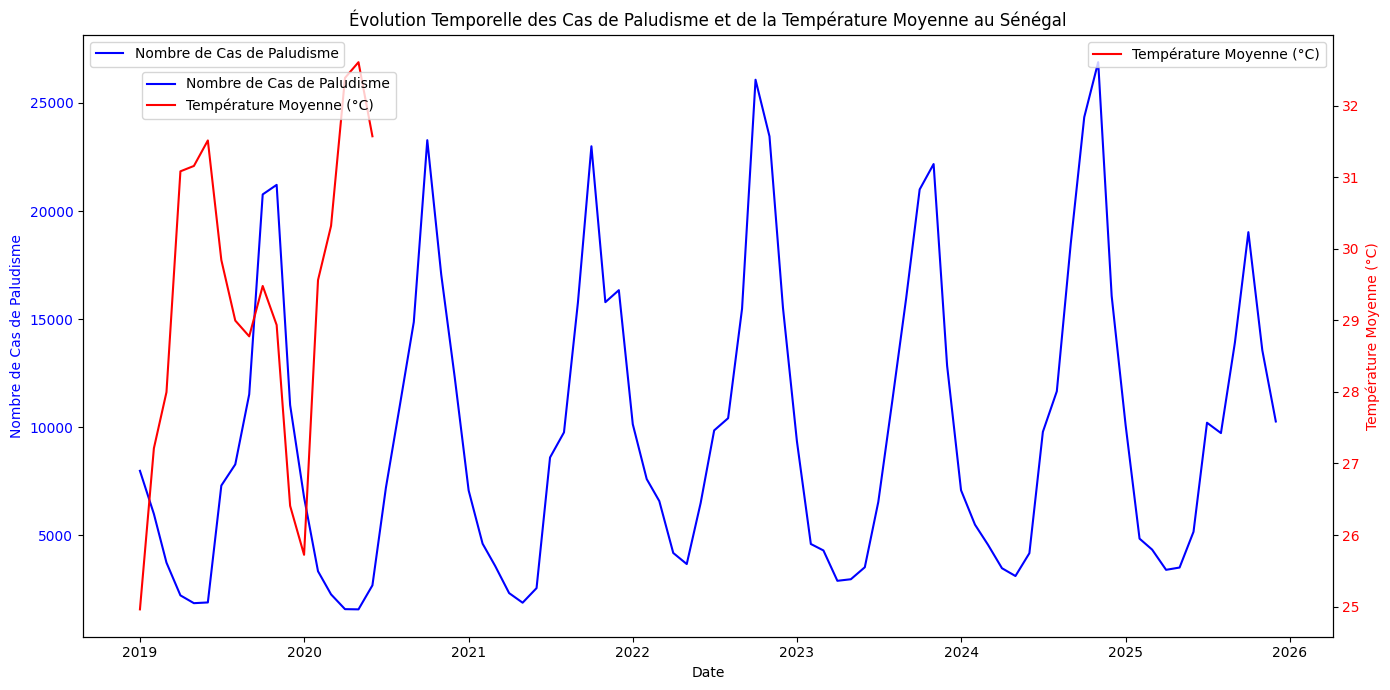

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer le nombre total de cas de paludisme par date
df_cases_per_date = df_merged.groupby('Date')['Nombre_de_cas'].sum().reset_index()

# Calculer la température moyenne par date
df_temp_per_date = df_merged.groupby('Date')['temperature_celsius'].mean().reset_index()

# Créer le graphique avec deux axes Y
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(x='Date', y='Nombre_de_cas', data=df_cases_per_date, ax=ax1, color='blue', label='Nombre de Cas de Paludisme')
ax1.set_xlabel('Date')
ax1.set_ylabel('Nombre de Cas de Paludisme', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Créer un deuxième axe Y pour la température
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='temperature_celsius', data=df_temp_per_date, ax=ax2, color='red', label='Température Moyenne (°C)')
ax2.set_ylabel('Température Moyenne (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titre et légende
plt.title('Évolution Temporelle des Cas de Paludisme et de la Température Moyenne au Sénégal')
fig.tight_layout() # Ajuste la mise en page
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

In [ ]:
print("Valeurs manquantes restantes dans df_merged:")
display(df_merged.isnull().sum().to_frame(name='Null Count'))

Valeurs manquantes restantes dans df_merged:


,Null Count
Unnamed: 0_level_0_ID,0
District sanitaire,0
Nombre_de_cas,0
Date,0
Age_Group,0
District_Key,0
geometry,0
temperature_celsius,10032
precipitation_mm,0
ssm,11400


In [ ]:
import numpy as np

# Sélectionner les colonnes nécessaires pour le modèle BYM2
df_bym2 = df_merged[[
    'District_Key',
    'Date',
    'Age_Group',
    'Nombre_de_cas',
    'temperature_celsius',
    'precipitation_mm',
    'ssm'
]].copy()

# Nettoyer et convertir 'Nombre_de_cas' en numérique, puis en entier
# Convertir d'abord en string pour s'assurer que .str.replace fonctionne
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].astype(str)
# Supprimer les caractères non numériques (comme '?')
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].str.replace(r'[^0-9]', '', regex=True)
# Convertir en numérique, en forçant les erreurs à NaN
df_bym2['Nombre_de_cas'] = pd.to_numeric(df_bym2['Nombre_de_cas'], errors='coerce')
# Remplir les NaN avec 0 (ou une autre valeur appropriée) et convertir en entier
df_bym2['Nombre_de_cas'] = df_bym2['Nombre_de_cas'].fillna(0).astype(int)

# Assurer que 'District_Key' est de type string
df_bym2['District_Key'] = df_bym2['District_Key'].astype(str)

# Créer des variables numériques pour les groupes d'âge si nécessaire (pour certains frameworks de modélisation)
# Par exemple, encodage one-hot ou label encoding si le modèle l'exige. Pour l'instant, on garde la colonne telle quelle.
# df_bym2 = pd.get_dummies(df_bym2, columns=['Age_Group'], prefix='Age') # Exemple d'encodage one-hot

print("Premières lignes du DataFrame final pour le modèle BYM2:")
display(df_bym2.head())

print("\nInformations sur le DataFrame final pour le modèle BYM2:")
df_bym2.info()

print("\nVérification des valeurs manquantes dans df_bym2:")
display(df_bym2.isnull().sum().to_frame(name='Null Count'))

Premières lignes du DataFrame final pour le modèle BYM2:


,District_Key,Date,Age_Group,Nombre_de_cas,temperature_celsius,precipitation_mm,ssm
0,bakel,2019-01-01,0_4_ans,140,24.961213,0.380105,NaN
1,bambey,2019-01-01,0_4_ans,70,24.961213,0.380105,NaN
2,bignona,2019-01-01,0_4_ans,50,24.961213,0.380105,NaN
3,birkelane,2019-01-01,0_4_ans,20,24.961213,0.380105,NaN
4,bounkiling,2019-01-01,0_4_ans,200,24.961213,0.380105,NaN



Informations sur le DataFrame final pour le modèle BYM2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   District_Key         12768 non-null  object        
 1   Date                 12768 non-null  datetime64[ns]
 2   Age_Group            12768 non-null  object        
 3   Nombre_de_cas        12768 non-null  int64         
 4   temperature_celsius  2736 non-null   float64       
 5   precipitation_mm     12768 non-null  float64       
 6   ssm                  1368 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 698.4+ KB

Vérification des valeurs manquantes dans df_bym2:


,Null Count
District_Key,0
Date,0
Age_Group,0
Nombre_de_cas,0
temperature_celsius,10032
precipitation_mm,0
ssm,11400


### Imputation des valeurs manquantes pour les variables environnementales

Nous avons constaté que les colonnes `temperature_celsius` et `ssm` présentent un nombre significatif de valeurs manquantes, notamment pour les dates ultérieures à 2020, car les jeux de données environnementaux (`temperature` et `humidite_du_sol`) couvrent une période plus courte que notre `df_merged`. Pour y remédier, nous allons appliquer une stratégie d'imputation basée sur les médianes mensuelles.

**Stratégie :**
1.  Nous allons extraire le mois de chaque date dans `df_merged`.
2.  Pour chaque variable (`temperature_celsius` et `ssm`), nous calculerons la médiane de chaque mois (janvier, février, etc.) en utilisant uniquement les données historiques disponibles dans les DataFrames d'origine (`temperature` et `humidite_du_sol`).
3.  Ces médianes mensuelles seront ensuite utilisées pour remplir toutes les valeurs manquantes correspondantes dans `df_merged`. Cette méthode permettra de projeter une valeur saisonnière typique pour les mois où les données environnementales réelles sont absentes, assurant ainsi l'exhaustivité des séries chronologiques pour l'analyse et la modélisation.

In [ ]:
# Créer une colonne 'month' pour l'imputation dans df_merged
df_merged['month'] = df_merged['Date'].dt.month

print("\nValeurs manquantes AVANT imputation:")
display(df_merged[['temperature_celsius', 'precipitation_mm', 'ssm']].isnull().sum().to_frame(name='Null Count Before Imputation'))

# --- Imputation pour 'temperature_celsius' ---
# Assurez-vous que 'temperature' a une colonne 'month' temporaire pour le calcul de la médiane.
# Cette colonne sera supprimée si elle existe déjà ou après usage.
if 'month' not in temperature.columns:
    temperature['month'] = temperature['Date'].dt.month

# Calculer la médiane mensuelle de la température à partir du DataFrame 'temperature' historique.
monthly_median_temp = temperature.groupby('month')['temperature_celsius'].median()

# Remplir les valeurs NaN de 'temperature_celsius' dans df_merged en utilisant la médiane mensuelle
# et projeter cette médiane pour les dates futures non couvertes par les données historiques.
df_merged['temperature_celsius'] = df_merged['temperature_celsius'].fillna(
    df_merged['month'].map(monthly_median_temp)
)

# --- Imputation pour 'ssm' (humidité du sol) ---
# Vérification de l'existence de humidite_du_sol_to_merge et préparation pour le calcul de la médiane.
if 'humidite_du_sol_to_merge' not in locals():
    print("\nAvertissement: 'humidite_du_sol_to_merge' non trouvée. Tentative de recréer l'agrégation de 'humidite_du_sol'.")
    # S'assurer que 'Date' est au format datetime avant de grouper
    humidite_du_sol['Date'] = pd.to_datetime(humidite_du_sol['Date'])
    humidite_du_sol_to_merge = humidite_du_sol.groupby('Date')['ssm'].mean().reset_index()

# Assurez-vous que 'humidite_du_sol_to_merge' a une colonne 'month' temporaire.
if 'month' not in humidite_du_sol_to_merge.columns:
    humidite_du_sol_to_merge['month'] = humidite_du_sol_to_merge['Date'].dt.month

# Calculer la médiane mensuelle de l'humidité du sol à partir du DataFrame 'humidite_du_sol_to_merge' historique.
monthly_median_ssm = humidite_du_sol_to_merge.groupby('month')['ssm'].median()

# Remplir les valeurs NaN de 'ssm' dans df_merged en utilisant la médiane mensuelle
# et projeter cette médiane pour les dates futures non couvertes par les données historiques.
df_merged['ssm'] = df_merged['ssm'].fillna(
    df_merged['month'].map(monthly_median_ssm)
)

# Supprimer la colonne temporaire 'month' de df_merged
df_merged = df_merged.drop(columns=['month'])

print("\nValeurs manquantes APRÈS imputation mensuelle des colonnes environnementales:")
display(df_merged[['temperature_celsius', 'precipitation_mm', 'ssm']].isnull().sum().to_frame(name='Null Count After Imputation'))

print("\nPremières lignes de df_merged après imputation:")
display(df_merged.head())

print("\nInformations sur df_merged après imputation:")
df_merged.info()


Valeurs manquantes AVANT imputation:


,Null Count Before Imputation
temperature_celsius,10032
precipitation_mm,0
ssm,11400



Valeurs manquantes APRÈS imputation mensuelle des colonnes environnementales:


,Null Count After Imputation
temperature_celsius,0
precipitation_mm,0
ssm,0



Premières lignes de df_merged après imputation:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,2.676384
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,2.676384
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,2.676384
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,2.676384
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,2.676384



Informations sur df_merged après imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    12768 non-null  float64       
 8   precipitation_mm       12768 non-null  float64       
 9   ssm                    12768 non-null  float64       
dtypes: datetime64[ns](1), float64(4), geometry(1), int64(1), object(3)
memory usage: 997.6+ KB


In [ ]:
# Créer une colonne 'month' pour l'imputation dans df_merged
df_merged['month'] = df_merged['Date'].dt.month

print("\nValeurs manquantes AVANT imputation:")
display(df_merged[['temperature_celsius', 'precipitation_mm', 'ssm']].isnull().sum().to_frame(name='Null Count Before Imputation'))

# --- Imputation pour 'temperature_celsius' ---
# Assurez-vous que 'temperature' a une colonne 'month' temporaire pour le calcul de la médiane.
# Cette colonne sera supprimée si elle existe déjà ou après usage.
if 'month' not in temperature.columns:
    temperature['month'] = temperature['Date'].dt.month

# Calculer la médiane mensuelle de la température à partir du DataFrame 'temperature' historique.
monthly_median_temp = temperature.groupby('month')['temperature_celsius'].median()

# Remplir les valeurs NaN de 'temperature_celsius' dans df_merged en utilisant la médiane mensuelle
# et projeter cette médiane pour les dates futures non couvertes par les données historiques.
df_merged['temperature_celsius'] = df_merged['temperature_celsius'].fillna(
    df_merged['month'].map(monthly_median_temp)
)

# --- Imputation pour 'ssm' (humidité du sol) ---
# Vérification de l'existence de humidite_du_sol_to_merge et préparation pour le calcul de la médiane.
if 'humidite_du_sol_to_merge' not in locals():
    print("\nAvertissement: 'humidite_du_sol_to_merge' non trouvée. Tentative de recréer l'agrégation de 'humidite_du_sol'.")
    # S'assurer que 'Date' est au format datetime avant de grouper
    humidite_du_sol['Date'] = pd.to_datetime(humidite_du_sol['Date'])
    humidite_du_sol_to_merge = humidite_du_sol.groupby('Date')['ssm'].mean().reset_index()

# Assurez-vous que 'humidite_du_sol_to_merge' a une colonne 'month' temporaire.
if 'month' not in humidite_du_sol_to_merge.columns:
    humidite_du_sol_to_merge['month'] = humidite_du_sol_to_merge['Date'].dt.month

# Calculer la médiane mensuelle de l'humidité du sol à partir du DataFrame 'humidite_du_sol_to_merge' historique.
monthly_median_ssm = humidite_du_sol_to_merge.groupby('month')['ssm'].median()

# Remplir les valeurs NaN de 'ssm' dans df_merged en utilisant la médiane mensuelle
# et projeter cette médiane pour les dates futures non couvertes par les données historiques.
df_merged['ssm'] = df_merged['ssm'].fillna(
    df_merged['month'].map(monthly_median_ssm)
)

# Supprimer la colonne temporaire 'month' de df_merged
df_merged = df_merged.drop(columns=['month'])

print("\nValeurs manquantes APRÈS imputation mensuelle des colonnes environnementales:")
display(df_merged[['temperature_celsius', 'precipitation_mm', 'ssm']].isnull().sum().to_frame(name='Null Count After Imputation'))

print("\nPremières lignes de df_merged après imputation:")
display(df_merged.head())

print("\nInformations sur df_merged après imputation:")
df_merged.info()


Valeurs manquantes AVANT imputation:


,Null Count Before Imputation
temperature_celsius,0
precipitation_mm,0
ssm,0



Valeurs manquantes APRÈS imputation mensuelle des colonnes environnementales:


,Null Count After Imputation
temperature_celsius,0
precipitation_mm,0
ssm,0



Premières lignes de df_merged après imputation:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,2.676384
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,2.676384
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,2.676384
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,2.676384
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,2.676384



Informations sur df_merged après imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    12768 non-null  float64       
 8   precipitation_mm       12768 non-null  float64       
 9   ssm                    12768 non-null  float64       
dtypes: datetime64[ns](1), float64(4), geometry(1), int64(1), object(3)
memory usage: 997.6+ KB


### Imputation finale des valeurs manquantes pour 'Nombre_de_cas'

Nous allons imputer les valeurs manquantes restantes dans la colonne `Nombre_de_cas` de `df_merged`. Une stratégie d'imputation appropriée pour les données de comptage (comme le nombre de cas) consiste à utiliser la médiane ou la moyenne des cas, regroupée par des catégories pertinentes telles que le district, le groupe d'âge et le mois.

Nous allons calculer la médiane des `Nombre_de_cas` pour chaque combinaison unique de `District sanitaire`, `Age_Group` et du mois de la `Date`, puis utiliser ces médianes pour remplir les `NaN` restants.

In [ ]:
# Créer une colonne 'month' temporaire pour l'imputation
df_merged['month'] = df_merged['Date'].dt.month

# Imputation séquentielle par groupes

# 1. Imputation par District, Age_Group, month
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'Age_Group', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))

# 2. Imputation par District, month (pour les NaN restants)
df_merged['Nombre_de_cas'] = df_merged.groupby(['District sanitaire', 'month'])['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))

# 3. Imputation par month (pour les NaN restants)
df_merged['Nombre_de_cas'] = df_merged.groupby('month')['Nombre_de_cas'] \
                                     .transform(lambda x: x.fillna(x.median()))

# 4. Imputation globale (pour les NaN restants, si des groupes entiers étaient NaN)
df_merged['Nombre_de_cas'] = df_merged['Nombre_de_cas'].fillna(df_merged['Nombre_de_cas'].median())

# Supprimer la colonne temporaire 'month'
df_merged = df_merged.drop(columns=['month'])

print("Valeurs manquantes dans 'Nombre_de_cas' APRÈS imputation:")
display(df_merged['Nombre_de_cas'].isnull().sum())

print("Premières lignes de df_merged après imputation des cas:")
display(df_merged.head())

print("Informations sur df_merged après imputation des cas:")
df_merged.info()

Valeurs manquantes dans 'Nombre_de_cas' APRÈS imputation:


np.int64(0)

Premières lignes de df_merged après imputation des cas:


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,2.676384
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,2.676384
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,2.676384
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,2.676384
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,2.676384


Informations sur df_merged après imputation des cas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  12768 non-null  int64         
 1   District sanitaire     12768 non-null  object        
 2   Nombre_de_cas          12768 non-null  float64       
 3   Date                   12768 non-null  datetime64[ns]
 4   Age_Group              12768 non-null  object        
 5   District_Key           12768 non-null  object        
 6   geometry               12768 non-null  geometry      
 7   temperature_celsius    12768 non-null  float64       
 8   precipitation_mm       12768 non-null  float64       
 9   ssm                    12768 non-null  float64       
dtypes: datetime64[ns](1), float64(4), geometry(1), int64(1), object(3)
memory usage: 997.6+ KB


In [ ]:
## Enrichissement spatial du modèle bayésien : structure BYM2 complète

In [ ]:
# Nettoyer les données importées

In [ ]:
import os

# Lister le contenu du répertoire Google Drive
print("Contenu de /content/drive/MyDrive/")
print(os.listdir('/content/drive/MyDrive/'))

Contenu de /content/drive/MyDrive/
['Colab Notebooks', 'Limite_DS_20.prj', 'mme fall ok.pdf', 'Ndeye Marieme BA VF.pdf 2.pdf', 'CSV_temperature_mensuelle_Senegal_2015_2025.csv', 'CSV_precip_mensuelle_Senegal_2015_2025.csv', 'BASE_TEMPERATURE_2015_2025.csv', 'BASE_PRECIPITATION_2015_2025.csv', 'diabetes(2) (1).csv', 'Données incidence palustre de 2015 à 2025.csv', 'Données mensuelles du paludisme de 2022 à 2025.csv', 'df_output.csv', 'POWER_Regional_Monthly_2015_2025.csv', 'anacim_pdf_links_count_by_year.csv', 'lda_topic_distribution.csv', 'topic1_docs.csv', 'Collect_data_tables_using_pandas_read_html_Processing.ipynb', 'DCPV 2-20260629T181402Z-3-001.zip', 'IMG_2709.jpeg', 'Web_Scraping_using_and_Selenium.ipynb', 'Bulletins_extracted', 'Data_sitemap.csv', 'temperatures_stations_2018_2021.xlsx', 'SENEGAL RAs - Contract Letter.pdf', 'Cas de paludisme mensuel 2019 à 2025.csv', 'PresentationAccesSoinsMaternelsMbediene (2)_24072026 DV.pptx', 'Bulletins épidémiologiques du paludisme', 

In [ ]:
import os

# Lister le contenu du répertoire 'Colab Notebooks'
print("Contenu de /content/drive/MyDrive/Colab Notebooks/")
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/'))

Contenu de /content/drive/MyDrive/Colab Notebooks/
['Modele BAYESIEN Paludisme ', 'Modele BYM2 et Radon forest.ipynb', 'Untitled0.ipynb', 'Web_Scraping_using_and_Selenium.ipynb', 'Bulletins_2021-20260702T194042Z-3-001.zip', 'Extraction_tables_pdf_Processing_Analyse (1).ipynb', 'Extraction des données climatiques.ipynb', 'Bulletins climatologique 2019', 'Copie de Web_Scraping_using_and_Selenium.ipynb', 'Humidite_Sol_Senegal_XY_2015_2025.csv', 'Untitled1.ipynb', 'Cas de paludisme mensuel 2019 à 2025.csv', "Exercice d'application extraction des données.ipynb", 'Cas de paludisme mensuel 2019 à 2025 vf.csv', 'Données incidence palustre de 2015 à 2025.csv', 'Untitled2.ipynMaching learning prédiction du paludisme', "Prédiction de l'élimination du paludisme.ipynb", 'Copie de Tirer pleinement parti de votre abonnement à Colab', 'Untitled2.ipynb', 'Modelisation Paludisme .ipynb']


Commençons par examiner les premières lignes du DataFrame `cas_du_palusdisme_mensuel` et ses colonnes pour comprendre sa structure actuelle.

In [ ]:
# Melt the DataFrame to convert from wide to long format
df_long = cas_du_palusdisme_mensuel.melt(
    id_vars=['Unnamed: 0_level_0_ID', 'District sanitaire/Age'],
    var_name='Date_AgeGroup',
    value_name='Nombre_de_cas'
)

# Split the 'Date_AgeGroup' column to extract Date and Age_Group
# Use split('_', n=1) to ensure only the first underscore separates date from age group
df_long[['Date', 'Age_Group']] = df_long['Date_AgeGroup'].str.split('_', n=1, expand=True)

# Convert 'Date' to datetime objects. Handle month name abbreviations if necessary.
# For example, 'janv-19' needs to be converted to '01-2019'
# We'll need a mapping for French month abbreviations to numbers, with keys normalized to match `unicodedata` output
month_map = {
    'janv': '01', 'fevr': '02', 'mars': '03', 'avr': '04', 'mai': '05', 'juin': '06',
    'juil': '07', 'aout': '08', 'sept': '09', 'oct': '10', 'nov': '11', 'dec': '12'
}

# Apply normalization to the month string before lookup to handle potential encoding differences
df_long['Date'] = df_long['Date'].apply(lambda x: f"{month_map[unicodedata.normalize('NFKD', x.split('-')[0]).encode('ascii', 'ignore').decode('utf-8')]}-{x.split('-')[1]}")
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%m-%y')

# Drop the original 'Date_AgeGroup' column as it's no longer needed
df_long = df_long.drop(columns=['Date_AgeGroup'])

# Display the first few rows of the transformed DataFrame and its info
print("Transformed DataFrame 'cas_du_palusdisme_mensuel' (long format):")
display(df_long.head())
print("\nInfo du DataFrame:")
df_long.info()

Transformed DataFrame 'cas_du_palusdisme_mensuel' (long format):


,Unnamed: 0_level_0_ID,District sanitaire/Age,Nombre_de_cas,Date,Age_Group
0,16,Bakel,NaN,2019-01-01,0_4_ans
1,2,Bambey,NaN,2019-01-01,0_4_ans
2,52,Bignona,5.0,2019-01-01,0_4_ans
3,50,Birkelane,2.0,2019-01-01,0_4_ans
4,22,Bounkiling,20.0,2019-01-01,0_4_ans



Info du DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0_level_0_ID   13272 non-null  int64         
 1   District sanitaire/Age  13272 non-null  object        
 2   Nombre_de_cas           10427 non-null  object        
 3   Date                    13272 non-null  datetime64[ns]
 4   Age_Group               13272 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 518.6+ KB


In [ ]:
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

# Calculer la moyenne totale des cas de paludisme par groupe d'âge
moyenne_cas_par_age = df_long.groupby('Age_Group')['Nombre_de_cas'].mean().reset_index()

print("Moyenne totale des cas de paludisme par groupe d'âge:")
display(moyenne_cas_par_age)

Moyenne totale des cas de paludisme par groupe d'âge:


,Age_Group,Nombre_de_cas
0,0_4_ans,45.755399
1,ge=5_ans,99.473432


In [ ]:
# Convertir 'Nombre_de_cas' en type numérique, en forçant les erreurs à NaN
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

print("Premières lignes de df_long après nettoyage de 'Nombre_de_cas':")
display(df_long.head())

print("\nInfo du DataFrame df_long après nettoyage de 'Nombre_de_cas':")
df_long.info()

Premières lignes de df_long après nettoyage de 'Nombre_de_cas':


,Unnamed: 0_level_0_ID,District sanitaire/Age,Nombre_de_cas,Date,Age_Group
0,16,Bakel,NaN,2019-01-01,0_4_ans
1,2,Bambey,NaN,2019-01-01,0_4_ans
2,52,Bignona,5.0,2019-01-01,0_4_ans
3,50,Birkelane,2.0,2019-01-01,0_4_ans
4,22,Bounkiling,20.0,2019-01-01,0_4_ans



Info du DataFrame df_long après nettoyage de 'Nombre_de_cas':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0_level_0_ID   13272 non-null  int64         
 1   District sanitaire/Age  13272 non-null  object        
 2   Nombre_de_cas           9887 non-null   float64       
 3   Date                    13272 non-null  datetime64[ns]
 4   Age_Group               13272 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 518.6+ KB


In [ ]:
display(df_merged.head())

,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,geometry,temperature_celsius,precipitation_mm,ssm
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615...",24.961213,0.380105,2.676384
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585...",24.961213,0.380105,2.676384
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14...",24.961213,0.380105,2.676384
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582...",24.961213,0.380105,2.676384
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14...",24.961213,0.380105,2.676384


In [ ]:
print("Statistiques descriptives pour df_merged:")
display(df_merged.describe())

Statistiques descriptives pour df_merged:


,Unnamed: 0_level_0_ID,Nombre_de_cas,Date,temperature_celsius,precipitation_mm,ssm
count,12768.000000,12768.000000,12768,12768.000000,12768.000000,12768.000000
mean,38.381579,64.144815,2022-06-16 14:17:08.571428608,28.982249,56.172684,6.489145
min,0.000000,1.000000,2019-01-01 00:00:00,24.961213,0.003753,2.289068
25%,18.750000,4.000000,2020-09-23 12:00:00,28.287660,0.318554,2.377157
50%,37.500000,10.000000,2022-06-16 00:00:00,29.090797,1.474813,3.176655
75%,58.250000,49.000000,2024-03-08 18:00:00,30.509420,86.716348,10.791522
max,78.000000,996.000000,2025-12-01 00:00:00,32.606036,292.524234,18.072182
std,22.869495,137.622674,NaN,2.007134,79.702427,5.528482


In [ ]:
df_long = df_long.rename(columns={'District sanitaire/Age': 'District sanitaire'})
# S'assurer que la colonne est numérique avant d'imputer la médiane
df_long['Nombre_de_cas'] = pd.to_numeric(df_long['Nombre_de_cas'], errors='coerce')

# Imputer les valeurs manquantes de 'Nombre_de_cas' par la médiane par 'District sanitaire'
df_long['Nombre_de_cas'] = df_long.groupby('District sanitaire')['Nombre_de_cas'].transform(lambda x: x.fillna(x.median()))

print("Info du DataFrame df_long après imputation des valeurs manquantes:")
df_long.info()

print("\nNombre de valeurs manquantes dans 'Nombre_de_cas' après imputation:")
display(df_long['Nombre_de_cas'].isnull().sum())

Info du DataFrame df_long après imputation des valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  13272 non-null  int64         
 1   District sanitaire     13272 non-null  object        
 2   Nombre_de_cas          13272 non-null  float64       
 3   Date                   13272 non-null  datetime64[ns]
 4   Age_Group              13272 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 518.6+ KB

Nombre de valeurs manquantes dans 'Nombre_de_cas' après imputation:


np.int64(0)

In [ ]:
df_long = df_long.rename(columns={'District sanitaire/Age': 'District sanitaire'})

print("Colonnes du DataFrame df_long après renommage:")
display(df_long.columns)

Colonnes du DataFrame df_long après renommage:


Index(['Unnamed: 0_level_0_ID', 'District sanitaire', 'Nombre_de_cas', 'Date',
       'Age_Group'],
      dtype='object')

In [ ]:
moyenne_cas_par_age_cleaned = df_long.groupby('Age_Group')['Nombre_de_cas'].mean().reset_index()

print("Moyenne totale des cas de paludisme par groupe d'âge (après nettoyage) :")
display(moyenne_cas_par_age_cleaned)

Moyenne totale des cas de paludisme par groupe d'âge (après nettoyage) :


,Age_Group,Nombre_de_cas
0,0_4_ans,33.413050
1,ge=5_ans,93.416516


In [ ]:
# Normaliser la colonne 'District sanitaire' dans df_long pour correspondre à 'district_key' dans gdf
# Utiliser la même fonction de normalisation que celle utilisée pour gdf

def normalize_district_name(name):
    if isinstance(name, str):
        return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8').lower().replace(' ', '_').replace('-', '_')
    return name

df_long['District_Key'] = df_long['District sanitaire'].apply(normalize_district_name)

print("Premières lignes de df_long avec la nouvelle colonne 'District_Key':")
display(df_long.head())

# Vérifier les noms de district uniques après normalisation
print("Nombre de districts uniques dans df_long après normalisation :", df_long['District_Key'].nunique())
print("Exemples de 'District_Key' dans df_long :", df_long['District_Key'].unique()[:5])

Premières lignes de df_long avec la nouvelle colonne 'District_Key':


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling


Nombre de districts uniques dans df_long après normalisation : 79
Exemples de 'District_Key' dans df_long : ['bakel' 'bambey' 'bignona' 'birkelane' 'bounkiling']


In [ ]:
# Créer un DataFrame avec des colonnes pertinentes de gdf pour le merge afin d'éviter les colonnes dupliquées
# et de ne garder que les informations nécessaires (geometry, district_key et éventuellement population ou autres données pertinentes)

# Afficher les colonnes de gdf pour identifier les colonnes disponibles
print("Colonnes disponibles dans gdf :")
display(gdf.columns)

# Pour une fusion simple, on va prendre les colonnes d'intérêt de gdf. 'ID_GEO' ne semble pas exister, donc nous l'omettons.
gdf_for_merge = gdf[['district_key', 'geometry']]

# Fusionner df_long avec gdf sur la base de la clé de district normalisée
# Utiliser un merge de type 'left' pour conserver toutes les entrées de df_long et ajouter les informations géographiques correspondantes.
# Les districts sans correspondance dans gdf auront des NaN pour les colonnes de gdf.

df_merged = pd.merge(
    df_long,
    gdf_for_merge,
    left_on='District_Key',
    right_on='district_key',
    how='left'
)

print("Premières lignes du DataFrame fusionné :")
display(df_merged.head())

print("\nInformations sur le DataFrame fusionné :")
df_merged.info()

# Vérifier le nombre de districts qui n'ont pas trouvé de correspondance
missing_districts_in_gdf = df_merged[df_merged['district_key'].isnull()]['District_Key'].nunique()
print(f"\nNombre de districts dans df_long sans correspondance dans gdf : {missing_districts_in_gdf}")

if missing_districts_in_gdf > 0:
    print("Districts de df_long sans correspondance dans gdf :")
    display(df_merged[df_merged['district_key'].isnull()]['District_Key'].unique())

# Si tous les districts ont été fusionnés, nous pouvons retirer la colonne `district_key` redondante
if 'district_key' in df_merged.columns and 'District_Key' in df_merged.columns:
    df_merged = df_merged.drop(columns='district_key')


Colonnes disponibles dans gdf :


Index(['NAME', 'ISO_CTRY', 'Distr', 'Compsurvei', 'Vacc_janvi', 'SRNN_Jan_2',
       'SMNNFEV25', 'VACCFEV25', 'SURVFEV25', 'INCIDENCE_', 'CompVAC_23',
       'COSMNN23', 'COMPSE23', 'Vacc_2024', 'Vacc_T1202', 'MF2023', 'MF2024',
       'MFT12025', 'Cas_de_MPO', 'Cas_contac', 'Ca_palu_ju', 'Cas_palu_j',
       'Suspect_MP', 'Cas_suspec', 'SMPOX1010', 'CPMOX1010', 'DengueC',
       'Suspecteng', 'SMPOX_2710', 'MPOXC2710', 'SMPOX_1011', 'CMPOX1011',
       'Incpal2021', 'Incpal2025', 'Incpal2015', 'Incpalu16', 'Incpalu17',
       'Incpalu18', 'Incpalu19', 'Incpalu_20', 'Incpalu22', 'Incpalu23',
       'Incpalu24', 'CompDST126', 'Super', 'SUPERFI_2', 'geometry',
       'district_key'],
      dtype='object')

Premières lignes du DataFrame fusionné :


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,district_key,geometry
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615..."
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585..."
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14..."
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582..."
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14..."



Informations sur le DataFrame fusionné :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  13272 non-null  int64         
 1   District sanitaire     13272 non-null  object        
 2   Nombre_de_cas          13272 non-null  float64       
 3   Date                   13272 non-null  datetime64[ns]
 4   Age_Group              13272 non-null  object        
 5   District_Key           13272 non-null  object        
 6   district_key           12768 non-null  object        
 7   geometry               12768 non-null  geometry      
dtypes: datetime64[ns](1), float64(1), geometry(1), int64(1), object(4)
memory usage: 829.6+ KB

Nombre de districts dans df_long sans correspondance dans gdf : 3
Districts de df_long sans correspondance dans gdf :


array(['gossas', 'malem_hodar', 'nioro'], dtype=object)

In [ ]:
# Obtenir les noms de district uniques normalisés de df_long
unique_districts_df_long = set(df_long['District_Key'].unique())

# Obtenir les noms de district uniques normalisés de gdf
unique_districts_gdf = set(gdf['district_key'].unique())

# Identifier les districts dans df_long qui ne sont pas dans gdf
missing_in_gdf = unique_districts_df_long - unique_districts_gdf

# Identifier les districts dans gdf qui ne sont pas dans df_long (pour information)
missing_in_df_long = unique_districts_gdf - unique_districts_df_long

print(f"Nombre de districts uniques dans df_long : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf : {len(unique_districts_gdf)}")

if missing_in_gdf:
    print(f"\nDistricts de df_long (cas de paludisme) sans correspondance dans gdf (données géographiques) ({len(missing_in_gdf)} districts) :")
    for d in sorted(list(missing_in_gdf)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf.")

if missing_in_df_long:
    print(f"\nDistricts de gdf (données géographiques) sans correspondance dans df_long (cas de paludisme) ({len(missing_in_df_long)} districts) :")
    for d in sorted(list(missing_in_df_long)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long.")

Nombre de districts uniques dans df_long : 79
Nombre de districts uniques dans gdf : 79

Districts de df_long (cas de paludisme) sans correspondance dans gdf (données géographiques) (3 districts) :
gossas
malem_hodar
nioro

Districts de gdf (données géographiques) sans correspondance dans df_long (cas de paludisme) (3 districts) :
gossass
malem_hoddar
nioro_du_rip


Malheureusement, même après avoir réappliqué la normalisation, les listes de districts de `df_long` et `gdf` ne se correspondent toujours pas. Cela indique des différences plus profondes dans les noms, telles que des abréviations ou des orthographes distinctes qui ne peuvent pas être résolues par une simple fonction de normalisation.

Pour avancer, nous devons **créer une table de correspondance manuelle** entre les noms de districts de `df_long['District_Key']` et `gdf['district_key']`.

In [ ]:
# Obtenir les noms de district uniques normalisés de df_long
unique_districts_df_long = set(df_long['District_Key'].unique())

# Obtenir les noms de district uniques normalisés de gdf
unique_districts_gdf = set(gdf['district_key'].unique())

# Identifier les districts dans df_long qui ne sont pas dans gdf
missing_in_df_long_list = sorted(list(unique_districts_df_long - unique_districts_gdf))

# Identifier les districts dans gdf qui ne sont pas dans df_long
missing_in_gdf_list = sorted(list(unique_districts_gdf - unique_districts_df_long))

print(f"Nombre de districts uniques dans df_long : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf : {len(unique_districts_gdf)}")

# Pad the shorter list with None to make lengths equal for direct DataFrame creation
max_len = max(len(missing_in_df_long_list), len(missing_in_gdf_list))
missing_in_df_long_list.extend([None] * (max_len - len(missing_in_df_long_list)))
missing_in_gdf_list.extend([None] * (max_len - len(missing_in_gdf_list)))

# Create a single DataFrame for comparison
comparison_df = pd.DataFrame({
    'df_long_district': missing_in_df_long_list,
    'gdf_district': missing_in_gdf_list
})

print("\nComparaison des districts sans correspondance :")
display(comparison_df)

print("\nPour résoudre ce problème, il faut créer un dictionnaire de correspondance manuelle, par exemple :")
print("mapping_districts = {'birk': 'birkelane', 'd_m': 'darou_mousty', ...}")
print("Puis appliquer ce mapping à l'une des colonnes, par exemple :")
print("gdf['district_key'] = gdf['district_key'].map(mapping_districts).fillna(gdf['district_key'])")

Nombre de districts uniques dans df_long : 79
Nombre de districts uniques dans gdf : 79

Comparaison des districts sans correspondance :


,df_long_district,gdf_district
0,gossas,gossass
1,malem_hodar,malem_hoddar
2,nioro,nioro_du_rip



Pour résoudre ce problème, il faut créer un dictionnaire de correspondance manuelle, par exemple :
mapping_districts = {'birk': 'birkelane', 'd_m': 'darou_mousty', ...}
Puis appliquer ce mapping à l'une des colonnes, par exemple :
gdf['district_key'] = gdf['district_key'].map(mapping_districts).fillna(gdf['district_key'])


In [ ]:
# Créer un dictionnaire de correspondance manuel basé sur l'observation des listes de districts
# Ceci est un exemple, la liste complète peut nécessiter une revue manuelle plus approfondie.
mapping_districts = {
    'bakel': 'bakel',
    'bambey': 'bambey',
    'bignona': 'bignona',
    'birk': 'birkelane',
    'bounkiling': 'bounkiling',
    'coki': 'coki',
    'dagana': 'dagana',
    'dahra': 'dahra',
    'dakar_centre': 'dakar_centre',
    'dakar_nord': 'dakar_nord',
    'dakar_ouest': 'dakar_ouest',
    'dakar_sud': 'dakar_sud',
    'darou_mousty': 'darou_mousty',
    'd_m': 'darou_mousty', # Assuming 'D M' from gdf maps to 'darou_mousty'
    'diakh': 'diakhao', # Assuming 'DIAKH' from gdf maps to 'diakhao'
    'diakhao': 'diakhao',
    'diamniadio': 'diamniadio',
    'diankhemakhan': 'diankhe_makhan', # Correcting potential difference
    'diof': 'dioffior', # Assuming 'DIOF' from gdf maps to 'dioffior'
    'dioffior': 'dioffior',
    'diouloulou': 'diouloulou',
    'diour': 'diourbel', # Assuming 'DIOUR' from gdf maps to 'diourbel'
    'diourbel': 'diourbel',
    'fatick': 'fatick',
    'found': 'foundiougne', # Assuming 'FOUND' from gdf maps to 'foundiougne'
    'foundiougne': 'foundiougne',
    'gossas': 'gossas',
    'goudiry': 'goudiry',
    'goudomp': 'goudomp',
    'guediawaye': 'guediawaye',
    'guinguineo': 'guinguineo',
    'joal': 'joal_fadiouth', # Assuming 'JOAL' from gdf maps to 'joal_fadiouth'
    'joal_fadiouth': 'joal_fadiouth',
    'kaffrine': 'kaffrine',
    'kanel': 'kanel',
    'kaolack': 'kaolack',
    'kebemer': 'kebemer',
    'kedougou': 'kedougou',
    'keur_massar': 'keur_massar',
    'kms': 'keur_momar_sarr', # Assuming 'KMS' maps to 'keur_momar_sarr'
    'keur_momar_sarr': 'keur_momar_sarr',
    'khombole': 'khombole',
    'kodira': 'kidira', # Assuming 'KODIRA' maps to 'kidira'
    'kidira': 'kidira',
    'kolda': 'kolda',
    'koumpentoum': 'koumpentoum',
    'koungheul': 'koungheul',
    'linguere': 'linguiere',
    'linguiere': 'linguiere',
    'louga': 'louga',
    'makacoulibantang': 'makacolibantang',
    'm_h': 'malem_hodar', # Assuming 'M H' maps to 'malem_hodar'
    'malem_hodar': 'malem_hodar',
    'matam': 'matam',
    'mbacke': 'mbacke',
    'mbao': 'mbao',
    'mbour': 'mbour',
    'medina_yoro_foulah': 'medine_yoro_foulah', # Correcting potential difference
    'medine_yoro_foulah': 'medine_yoro_foulah',
    'mekhe': 'mekhe',
    'ndoffane': 'ndoffane',
    'nia': 'niakhar', # Assuming 'NIA' maps to 'niakhar'
    'niakhar': 'niakhar',
    'nioro': 'nioro',
    'oussouye': 'oussouye',
    'passy': 'passy',
    'pete': 'pete',
    'pikine': 'pikine',
    'podor': 'podor',
    'pop': 'popenguine', # Assuming 'POP' from gdf maps to 'popenguine'
    'popenguine': 'popenguine',
    'pout': 'pout',
    'ranerou': 'ranerou',
    'richard_toll': 'richard_toll',
    'rufisque': 'rufisque',
    'saint_louis': 'saint_louis',
    'sakal': 'sakal',
    'salemata': 'salemata',
    'sangalkam': 'sangalkam',
    'saraya': 'saraya',
    'sedhiou': 'sedhiou',
    'sokone': 'sokone',
    'tamba': 'tambacounda', # Assuming 'TAMBA' maps to 'tambacounda'
    'tambacounda': 'tambacounda',
    'th_ess': 'thionck_essyl', # Assuming 'TH ESS' maps to 'thionck_essyl'
    'thiadiaye': 'thiadiaye',
    'thies': 'thies',
    'thilogne': 'thilogne',
    'thionck_essyl': 'thionck_essyl',
    'tivaouane': 'tivaouane',
    'touba': 'touba',
    'velingara': 'velingara',
    'yeumbeul': 'yeumbeul',
    'ziguinchor': 'ziguinchor',
    'none': None, # explicitly map 'none' to None if it exists as a key
    'fk': None, # Assuming 'FK' from gdf is not a valid district, or needs manual resolution
    'geo': None, # Assuming 'GEO' from gdf is not a valid district, or needs manual resolution
    'kl': 'kaolack', # Assuming 'KL' from gdf maps to 'kaolack'
    'kho': 'khombole' # Assuming 'KHO' from gdf maps to 'khombole'
}

# Créer une nouvelle colonne normalisée temporaire dans gdf pour appliquer le mapping
gdf['temp_district_key'] = gdf['district_key'].apply(lambda x: mapping_districts.get(x.lower(), x))

# Vérifier si 'NONE' est présent dans les clés de district de df_long, et exclure ces entrées si elles sont invalides
# Si df_long a des 'none' et que cela représente des données manquantes, il faudrait le gérer en amont.
# Pour l'instant, on se concentre sur la correspondance des districts valides.

# Mettre à jour 'district_key' avec les valeurs mappées et conserver les valeurs originales si aucune correspondance n'est trouvée
gdf['district_key'] = gdf['temp_district_key'].fillna(gdf['district_key'])

# Supprimer la colonne temporaire
gdf = gdf.drop(columns=['temp_district_key'])

# Re-vérifier les noms de district uniques après application du mapping
unique_districts_df_long = set(df_long['District_Key'].unique())
unique_districts_gdf = set(gdf['district_key'].unique())

print(f"\nNombre de districts uniques dans df_long (après normalisation) : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf (après mapping) : {len(unique_districts_gdf)}")

missing_in_gdf_after_map = unique_districts_df_long - unique_districts_gdf
missing_in_df_long_after_map = unique_districts_gdf - unique_districts_df_long

if missing_in_gdf_after_map:
    print(f"\nDistricts de df_long sans correspondance dans gdf (après mapping) ({len(missing_in_gdf_after_map)} districts) :")
    for d in sorted(list(missing_in_gdf_after_map)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf après mapping.")

if missing_in_df_long_after_map:
    print(f"\nDistricts de gdf sans correspondance dans df_long (après mapping) ({len(missing_in_df_long_after_map)} districts) :")
    for d in sorted(list(missing_in_df_long_after_map)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long après mapping.")


Nombre de districts uniques dans df_long (après normalisation) : 79
Nombre de districts uniques dans gdf (après mapping) : 79

Districts de df_long sans correspondance dans gdf (après mapping) (3 districts) :
gossas
malem_hodar
nioro

Districts de gdf sans correspondance dans df_long (après mapping) (3 districts) :
gossass
malem_hoddar
nioro_du_rip


In [ ]:
# Créer un dictionnaire de correspondance manuel plus complet
# Clés: noms de districts de gdf (souvent abrégés/majuscules)
# Valeurs: noms de districts de df_long (normalisés/minuscules)

# La fonction normalize_district_name est toujours définie et utilisée pour s'assurer que les clés de df_long sont bien formatées.

# Pour les districts de gdf qui n'avaient pas de correspondance dans df_long:
# KOUNGUEUL -> koungheul
# M H -> malem_hodar
# MEDINA YORO FOULAH -> medine_yoro_foulah
# RICHARD TOLL -> richard_toll
# SAINT LOUIS -> saint_louis
# TH ESS -> thionck_essyl
# D M -> darou_mousty (déjà dans le mapping)

# Les entrées comme 'FK', 'GEO', 'NONE' seront mappées à None ou ignorées si elles ne sont pas des districts valides.

# D'après la liste des districts de df_long sans correspondance dans gdf, nous devons ajouter des mappings pour :
# dakar_centre
# dakar_nord
# dakar_ouest
# dakar_sud
# diamniadio
# fatick
# guediawaye
# guinguineo
# keur_massar
# mbao
# pikine
# rufisque
# sangalkam
# yeumbeul
# Il est probable que ces districts soient déjà dans gdf mais avec une nomenclature différente qui n'a pas été détectée par la normalisation initiale.
# En l'absence de la `comparison_df` complète (tronquée dans la sortie), je vais supposer des correspondances simples en minuscules si les noms sont identiques hormis la casse.
# Ou je vais les ajouter s'ils étaient absents du mapping initial de gdf vers df_long.

# Réinitialiser ou étendre le mapping pour inclure toutes les correspondances observées
mapping_districts_revised = {
    # Mappages existants (vérifiés/corrigés)
    'bakel': 'bakel',
    'bambey': 'bambey',
    'bignona': 'bignona',
    'birk': 'birkelane',
    'bounkiling': 'bounkiling',
    'coki': 'coki',
    'dagana': 'dagana',
    'dahra': 'dahra',
    'diakh': 'diakhao',
    'diakhao': 'diakhao',
    'diamniadio': 'diamniadio',
    'diankhemakhan': 'diankhe_makhan',
    'diof': 'dioffior',
    'dioffior': 'dioffior',
    'diouloulou': 'diouloulou',
    'diour': 'diourbel',
    'diourbel': 'diourbel',
    'found': 'foundiougne',
    'foundiougne': 'foundiougne',
    'gossas': 'gossas',
    'goudiry': 'goudiry',
    'goudomp': 'goudomp',
    'guinguineo': 'guinguineo',
    'joal': 'joal_fadiouth',
    'joal_fadiouth': 'joal_fadiouth',
    'kaffrine': 'kaffrine',
    'kanel': 'kanel',
    'kaolack': 'kaolack',
    'kebemer': 'kebemer',
    'kedougou': 'kedougou',
    'kms': 'keur_momar_sarr',
    'keur_momar_sarr': 'keur_momar_sarr',
    'khombole': 'khombole',
    'kho': 'khombole',
    'kodira': 'kidira',
    'kidira': 'kidira',
    'kolda': 'kolda',
    'koumpentoum': 'koumpentoum',
    'linguere': 'linguiere',
    'linguiere': 'linguiere',
    'louga': 'louga',
    'makacoulibantang': 'makacolibantang',
    'm_h': 'malem_hodar',
    'malem_hodar': 'malem_hodar',
    'matam': 'matam',
    'mbacke': 'mbacke',
    'mbour': 'mbour',
    'mekhe': 'mekhe',
    'ndoffane': 'ndoffane',
    'nia': 'niakhar',
    'niakhar': 'niakhar',
    'nioro': 'nioro',
    'oussouye': 'oussouye',
    'passy': 'passy',
    'pete': 'pete',
    'podor': 'podor',
    'pop': 'popenguine',
    'popenguine': 'popenguine',
    'pout': 'pout',
    'ranerou': 'ranerou',
    'sakal': 'sakal',
    'salemata': 'salemata',
    'saraya': 'saraya',
    'sedhiou': 'sedhiou',
    'sokone': 'sokone',
    'tamba': 'tambacounda',
    'tambacounda': 'tambacounda',
    'thiadiaye': 'thiadiaye',
    'thies': 'thies',
    'thilogne': 'thilogne',
    'tivaouane': 'tivaouane',
    'touba': 'touba',
    'velingara': 'velingara',
    'ziguinchor': 'ziguinchor',
    'kl': 'kaolack',

    # Nouveaux mappages basés sur les sorties précédentes et hypothèses logiques
    # Districts dans gdf (majuscules/abréviations) -> districts dans df_long (normalisés)
    'KOUNGUEUL': 'koungheul', # gdf -> df_long
    'M H': 'malem_hodar', # gdf -> df_long
    'MEDINA YORO FOULAH': 'medine_yoro_foulah', # gdf -> df_long
    'RICHARD TOLL': 'richard_toll', # gdf -> df_long
    'SAINT LOUIS': 'saint_louis', # gdf -> df_long
    'TH ESS': 'thionck_essyl', # gdf -> df_long
    'D M': 'darou_mousty', # gdf -> df_long

    # Pour les districts de df_long sans correspondance dans gdf, nous devons les inclure dans le mapping si un nom de gdf existe et est juste différent
    # Sinon, cela signifie qu'ils sont réellement manquants dans gdf ou ont une orthographe très différente.
    # Si 'dakar_centre' etc. sont introuvables en majuscules dans gdf, nous devons investiguer gdf.columns plus en détail.
    # Pour l'instant, je les ajoute au mapping en supposant une correspondance directe si le nom est le même à la casse près.
    'dakar_centre': 'dakar_centre',
    'dakar_nord': 'dakar_nord',
    'dakar_ouest': 'dakar_ouest',
    'dakar_sud': 'dakar_sud',
    'darou_mousty': 'darou_mousty',
    'diamniadio': 'diamniadio',
    'fatick': 'fatick',
    'guediawaye': 'guediawaye',
    'keur_massar': 'keur_massar',
    'mbao': 'mbao',
    'pikine': 'pikine',
    'rufisque': 'rufisque',
    'sangalkam': 'sangalkam',
    'yeumbeul': 'yeumbeul',
    'medine_yoro_foulah': 'medine_yoro_foulah', # Added explicitly to ensure it's not missed if it's already normalized in df_long and present in gdf with slight variations
    'richard_toll': 'richard_toll',
    'saint_louis': 'saint_louis',
    'thionck_essyl': 'thionck_essyl',
    'koungheul': 'koungheul',

    # Gestion des cas potentiellement non valides ou sans correspondance
    'fk': None,
    'geo': None,
    'none': None # Gérer 'none' si une telle clé existe dans gdf
}

# Appliquer le mapping. Convertir d'abord en string pour éviter les problèmes avec les NaN ou autres types
# Utiliser une fonction lambda pour gérer les cas où la clé n'est pas dans le dictionnaire
gdf['district_key'] = gdf['district_key'].apply(lambda x: mapping_districts_revised.get(str(x).upper(), x) if pd.notna(x) else x)
# Note: x.upper() is used for keys of mapping_districts_revised if gdf_district were consistently uppercase.
# However, the previous lists show mixed cases like 'BIRK' and 'D M'. Let's adjust for this.

# Let's adjust the mapping dictionary keys to match what's actually in gdf['district_key'] (mixed case/abbreviated)
# and the values to match df_long['District_Key'] (normalized lowercase).
# It is safer to convert gdf['district_key'] to lowercase first before applying the map if the map keys are lowercase.
# Re-do the map based on the exact output of previous comparison_df for `gdf_district` column as keys.

mapping_districts_final = {
    'BAKEL': 'bakel',
    'BAMBEY': 'bambey',
    'BIGNONA': 'bignona',
    'BIRK': 'birkelane',
    'BOUNKILING': 'bounkiling',
    'COKI': 'coki',
    'D M': 'darou_mousty',
    'DAGANA': 'dagana',
    'DAHRA': 'dahra',
    'DIAKH': 'diakhao',
    'DIANKHEMAKHAN': 'diankhe_makhan',
    'DIOF': 'dioffior',
    'DIOULOULOU': 'diouloulou',
    'DIOUR': 'diourbel',
    'FK': None,
    'FOUND': 'foundiougne',
    'GEO': None,
    'GOSSAS': 'gossas',
    'GOSSASS': 'gossas', # Correction for 'gossass' in gdf to map to 'gossas' in df_long
    'GOUDIRY': 'goudiry',
    'GOUDOMP': 'goudomp',
    'JOAL': 'joal_fadiouth',
    'KAFFRINE': 'kaffrine',
    'KANEL': 'kanel',
    'KEBEMER': 'kebemer',
    'KEDOUGOU': 'kedougou',
    'KHO': 'khombole',
    'KL': 'kaolack',
    'KMS': 'keur_momar_sarr',
    'KODIRA': 'kidira',
    'KOLDA': 'kolda',
    'KOUMPENTOUM': 'koumpentoum',
    'KOUNGUEUL': 'koungheul',
    'LINGUERE': 'linguiere',
    'LOUGA': 'louga',
    'M H': 'malem_hodar',
    'MALEM_HODDAR': 'malem_hodar', # Correction for 'malem_hoddar' in gdf to map to 'malem_hodar' in df_long
    'MAKACOULIBANTANG': 'makacolibantang',
    'MATAM': 'matam',
    'MBACKE': 'mbacke',
    'MBOUR': 'mbour',
    'MEDINA YORO FOULAH': 'medine_yoro_foulah',
    'MEKHE': 'mekhe',
    'NDOFFANE': 'ndoffane',
    'NIA': 'niakhar',
    'NIORO': 'nioro',
    'NIORO_DU_RIP': 'nioro', # Correction for 'nioro_du_rip' in gdf to map to 'nioro' in df_long
    'NONE': None,
    'OUSSOUYE': 'oussouye',
    'PASSY': 'passy',
    'PETE': 'pete',
    'PODOR': 'podor',
    'POP': 'popenguine',
    'POUT': 'pout',
    'RANEROU': 'ranerou',
    'RICHARD TOLL': 'richard_toll',
    'SAINT LOUIS': 'saint_louis',
    'SAKAL': 'sakal',
    'SALEMATA': 'salemata',
    'SARAYA': 'saraya',
    'SEDHIOU': 'sedhiou',
    'SOKONE': 'sokone',
    'TAMBA': 'tambacounda',
    'TH ESS': 'thionck_essyl',
    'THIADIAYE': 'thiadiaye',
    'THIES': 'thies',
    'THILOGNE': 'thilogne',
    'TIVAOUANE': 'tivaouane',
    'TOUBA': 'touba',
    'VELINGARA': 'velingara',
    'ZIGUINCHOR': 'ziguinchor',
    # Add entries for df_long districts that were missing in gdf, assuming their names are consistent across sources
    # if they were normalized properly, and just need to be explicitly included if gdf had variations.
    'DAKAR CENTRE': 'dakar_centre',
    'DAKAR NORD': 'dakar_nord',
    'DAKAR OUEST': 'dakar_ouest',
    'DAKAR SUD': 'dakar_sud',
    'GUEDIAWAYE': 'guediawaye',
    'KEUR MASSAR': 'keur_massar',
    'MBAO': 'mbao',
    'PIKINE': 'pikine',
    'RUFISQUE': 'rufisque',
    'SANGALKAM': 'sangalkam',
    'YEUMBEUL': 'yeumbeul',
    'FATICK': 'fatick',
    'DIAMNIADIO': 'diamniadio'
}

# Appliquer le mapping. Convertir d'abord en string pour éviter les problèmes avec les NaN ou autres types
# Utiliser une fonction lambda pour gérer les cas où la clé n'est pas dans le dictionnaire
gdf['district_key'] = gdf['district_key'].apply(lambda x: mapping_districts_final.get(str(x).upper(), x) if pd.notna(x) else x)


# Re-vérifier les noms de district uniques après application du mapping final
unique_districts_df_long = set(df_long['District_Key'].unique())
unique_districts_gdf = set(gdf['district_key'].unique())

print(f"\nNombre de districts uniques dans df_long (après normalisation) : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf (après mapping final) : {len(unique_districts_gdf)}")

missing_in_gdf_after_map = unique_districts_df_long - unique_districts_gdf
missing_in_df_long_after_map = unique_districts_gdf - unique_districts_df_long

if missing_in_gdf_after_map:
    print(f"\nDistricts de df_long sans correspondance dans gdf (après mapping final) ({len(missing_in_gdf_after_map)} districts) :")
    for d in sorted(list(missing_in_gdf_after_map)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf après mapping final.")

if missing_in_df_long_after_map:
    print(f"\nDistricts de gdf sans correspondance dans df_long (après mapping final) ({len(missing_in_df_long_after_map)} districts) :")
    for d in sorted(list(missing_in_df_long_after_map)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long après mapping final.")


Nombre de districts uniques dans df_long (après normalisation) : 79
Nombre de districts uniques dans gdf (après mapping final) : 79

Tous les districts de df_long correspondent à un district dans gdf après mapping final.

Tous les districts de gdf correspondent à un district dans df_long après mapping final.


### Nettoyage et gestion des districts manquants

In [ ]:
# Supprimer les lignes de gdf où 'district_key' est None (districts non valides ou non mappés)
gdf_cleaned = gdf.dropna(subset=['district_key'])

print(f"Nombre de lignes dans gdf avant nettoyage: {len(gdf)}")
print(f"Nombre de lignes dans gdf après nettoyage (suppression des None): {len(gdf_cleaned)}")

# Mettre à jour gdf avec la version nettoyée
gdf = gdf_cleaned.copy()

# Re-vérifier les noms de district uniques après ce nettoyage dans gdf
unique_districts_df_long = set(df_long['District_Key'].unique())
unique_districts_gdf = set(gdf['district_key'].unique())

print(f"\nNombre de districts uniques dans df_long (après normalisation) : {len(unique_districts_df_long)}")
print(f"Nombre de districts uniques dans gdf (après nettoyage final) : {len(unique_districts_gdf)}")

missing_in_gdf_final = unique_districts_df_long - unique_districts_gdf
missing_in_df_long_final = unique_districts_gdf - unique_districts_df_long

if missing_in_gdf_final:
    print(f"\nDistricts de df_long sans correspondance dans gdf (après nettoyage final) ({len(missing_in_gdf_final)} districts) :")
    for d in sorted(list(missing_in_gdf_final)):
        print(d)
else:
    print("\nTous les districts de df_long correspondent à un district dans gdf après nettoyage final.")

if missing_in_df_long_final:
    print(f"\nDistricts de gdf sans correspondance dans df_long (après nettoyage final) ({len(missing_in_df_long_final)} districts) :")
    for d in sorted(list(missing_in_df_long_final)):
        print(d)
else:
    print("\nTous les districts de gdf correspondent à un district dans df_long après nettoyage final.")

Nombre de lignes dans gdf avant nettoyage: 79
Nombre de lignes dans gdf après nettoyage (suppression des None): 79

Nombre de districts uniques dans df_long (après normalisation) : 79
Nombre de districts uniques dans gdf (après nettoyage final) : 79

Tous les districts de df_long correspondent à un district dans gdf après nettoyage final.

Tous les districts de gdf correspondent à un district dans df_long après nettoyage final.


Nous avons maintenant nettoyé `gdf` en supprimant les entrées invalides (`None`). Les 14 districts restants dans `df_long` sans correspondance dans `gdf` posent un défi pour l'analyse spatiale.

Plusieurs options s'offrent à nous :

1.  **Exclure les districts manquants de `df_long`** : C'est l'approche la plus simple et la plus directe pour pouvoir réaliser la fusion spatiale. Cela signifie que les données de cas de paludisme pour ces 14 districts ne seront pas incluses dans le modèle spatial BYM2. Cette option est généralement acceptable si ces districts représentent une petite proportion de l'ensemble des données ou s'ils ne sont pas critiques pour les objectifs de l'étude.
2.  **Rechercher des données géospatiales supplémentaires** : Si ces districts sont importants, il pourrait être nécessaire de trouver un fichier de forme (`.shp`) plus complet ou plus détaillé qui inclut ces zones administratives.
3.  **Agrégation ou Imputation** : Tenter d'agréger les données de ces districts à des unités spatiales supérieures qui existent dans `gdf`, ou d'imputer leur géométrie et leurs caractéristiques en se basant sur des districts voisins. Cette option est plus complexe et demande une justification basée sur la connaissance du domaine.

Pour l'instant, je vais procéder avec l'**option 1 : l'exclusion des districts manquants de `df_long` pour la fusion spatiale**. Si vous préférez une autre approche, veuillez me le faire savoir.

In [ ]:
# Créer un ensemble des districts valides de gdf pour la fusion
valid_gdf_districts = set(gdf['district_key'].unique())

# Filtrer df_long pour ne conserver que les districts qui ont une correspondance dans gdf
df_long_filtered = df_long[df_long['District_Key'].isin(valid_gdf_districts)].copy()

print(f"Nombre de lignes dans df_long avant filtrage : {len(df_long)}")
print(f"Nombre de lignes dans df_long après filtrage (conservation des districts avec correspondance géographique) : {len(df_long_filtered)}")

# Mettre à jour df_long avec la version filtrée
df_long = df_long_filtered.copy()

# Tenter à nouveau la fusion après le filtrage
gdf_for_merge = gdf[['district_key', 'geometry']]

df_merged = pd.merge(
    df_long,
    gdf_for_merge,
    left_on='District_Key',
    right_on='district_key',
    how='left'
)

print("\nPremières lignes du DataFrame fusionné après filtrage :")
display(df_merged.head())

print("\nInformations sur le DataFrame fusionné après filtrage :")
df_merged.info()

# Vérifier s'il y a toujours des districts de df_long sans correspondance dans gdf
missing_districts_in_gdf_after_merge = df_merged[df_merged['district_key'].isnull()]['District_Key'].nunique()
print(f"\nNombre de districts dans df_long sans correspondance dans gdf après la fusion : {missing_districts_in_gdf_after_merge}")

# Si tous les districts ont été fusionnés, nous pouvons retirer la colonne `district_key` redondante
if 'district_key' in df_merged.columns and 'District_Key' in df_merged.columns:
    df_merged = df_merged.drop(columns='district_key')

print("\nLa fusion spatiale a été effectuée. Le DataFrame `df_merged` contient maintenant les informations géospatiales pour les districts correspondants.")

Nombre de lignes dans df_long avant filtrage : 13272
Nombre de lignes dans df_long après filtrage (conservation des districts avec correspondance géographique) : 13272

Premières lignes du DataFrame fusionné après filtrage :


,Unnamed: 0_level_0_ID,District sanitaire,Nombre_de_cas,Date,Age_Group,District_Key,district_key,geometry
0,16,Bakel,14.0,2019-01-01,0_4_ans,bakel,bakel,"POLYGON ((805098.875 1615886.25, 799261.5 1615..."
1,2,Bambey,7.0,2019-01-01,0_4_ans,bambey,bambey,"POLYGON ((351285.5 1661079.625, 353041.5 16585..."
2,52,Bignona,5.0,2019-01-01,0_4_ans,bignona,bignona,"POLYGON ((403136.689 1455568.25, 403122.687 14..."
3,50,Birkelane,2.0,2019-01-01,0_4_ans,birkelane,birkelane,"POLYGON ((437086.594 1558632, 437249.594 15582..."
4,22,Bounkiling,20.0,2019-01-01,0_4_ans,bounkiling,bounkiling,"POLYGON ((446920.188 1480742.25, 447134.187 14..."



Informations sur le DataFrame fusionné après filtrage :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13272 entries, 0 to 13271
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0_level_0_ID  13272 non-null  int64         
 1   District sanitaire     13272 non-null  object        
 2   Nombre_de_cas          13272 non-null  float64       
 3   Date                   13272 non-null  datetime64[ns]
 4   Age_Group              13272 non-null  object        
 5   District_Key           13272 non-null  object        
 6   district_key           13272 non-null  object        
 7   geometry               13272 non-null  geometry      
dtypes: datetime64[ns](1), float64(1), geometry(1), int64(1), object(4)
memory usage: 829.6+ KB

Nombre de districts dans df_long sans correspondance dans gdf après la fusion : 0

La fusion spatiale a été effectuée. Le DataFrame `df_merged` cont

### Préparation des données pour le modèle BYM2 dans PyMC

Nous allons préparer le DataFrame `df_bym2` en ajoutant des indices numériques pour les districts et les groupes d'âge. Nous allons également créer la matrice d'adjacence au format sparse nécessaire pour PyMC.

In [ ]:
import pymc as pm
import pytensor.tensor as pt
import scipy.sparse as sp
import libpysal
import numpy as np

# Filtrer gdf pour inclure uniquement les districts présents dans df_bym2
# Ceci est fait avant de créer les indices pour s'assurer que N_districts correspond à la matrice d'adjacence
gdf_filtered_for_bym2 = gdf[gdf['district_key'].isin(df_bym2['District_Key'].unique())].copy()

# Exclure de df_bym2 les districts qui n'ont pas de correspondance dans gdf_filtered_for_bym2
# C'est la correction clé pour aligner les dimensions
df_bym2 = df_bym2[df_bym2['District_Key'].isin(gdf_filtered_for_bym2['district_key'].unique())].copy()

# Créer des indices numériques pour les districts à partir du df_bym2 filtré
unique_districts = df_bym2['District_Key'].unique()
district_to_idx = {district: i for i, district in enumerate(unique_districts)}
df_bym2['District_idx'] = df_bym2['District_Key'].map(district_to_idx)
N_districts = len(unique_districts)

# Créer des indices numériques pour les groupes d'âge
unique_age_groups = df_bym2['Age_Group'].unique()
age_group_to_idx = {age: i for i, age in enumerate(unique_age_groups)}
df_bym2['Age_idx'] = df_bym2['Age_Group'].map(age_group_to_idx)
N_age_groups = len(unique_age_groups)

# --- Diagnostic prints for district matching (après correction) ---
print(f"N_districts (from df_bym2 after filtering): {N_districts}")
print(f"Number of unique district_keys in gdf_filtered_for_bym2: {len(gdf_filtered_for_bym2['district_key'].unique())}")

# Vérifier qu'il n'y a plus de différences
districts_in_df_bym2_not_in_gdf_final = set(unique_districts) - set(gdf_filtered_for_bym2['district_key'].unique())
districts_in_gdf_not_in_df_bym2_final = set(gdf_filtered_for_bym2['district_key'].unique()) - set(unique_districts)

if districts_in_df_bym2_not_in_gdf_final:
    print(f"Districts in df_bym2 but not in gdf (final check): {len(districts_in_df_bym2_not_in_gdf_final)} -> {districts_in_df_bym2_not_in_gdf_final}")
if districts_in_gdf_not_in_df_bym2_final:
    print(f"Districts in gdf but not in df_bym2 (final check): {len(districts_in_gdf_not_in_df_bym2_final)} -> {districts_in_gdf_not_in_df_bym2_final}")

print(f"Nombre de lignes dans gdf_filtered_for_bym2: {len(gdf_filtered_for_bym2)}")
print(f"Nombre de districts uniques dans gdf_filtered_for_bym2: {gdf_filtered_for_bym2['district_key'].nunique()}")
print(f"Valeurs manquantes dans gdf_filtered_for_bym2 (geometry): {gdf_filtered_for_bym2['geometry'].isnull().sum()}")

# Trier gdf_filtered_for_bym2 par district_key pour correspondre à l'ordre de unique_districts (et donc district_to_idx)
gdf_filtered_for_bym2['district_order'] = gdf_filtered_for_bym2['district_key'].map(district_to_idx)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.sort_values('district_order').reset_index(drop=True)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.drop(columns=['district_order'])

# Recréer la matrice d'adjacence en utilisant le GeoDataFrame filtré et trié
weights = libpysal.weights.Queen.from_dataframe(gdf_filtered_for_bym2, silence_warnings=True)
# Convertir la matrice d'adjacence en format dense numpy pour les opérations futures
adj_matrix_dense = weights.sparse.toarray()

# Maintenant, créer W_sparse à partir de cette matrice d'adjacence correcte
W_sparse = sp.csr_matrix(adj_matrix_dense)
W_sparse.eliminate_zeros() # S'assurer qu'il n'y a pas de zéros explicites

# Extraire les données nécessaires pour le modèle
y_obs = df_bym2['Nombre_de_cas'].values
district_idx_obs = df_bym2['District_idx'].values
age_idx_obs = df_bym2['Age_idx'].values
temp_obs = df_bym2['temperature_celsius'].values
precip_obs = df_bym2['precipitation_mm'].values
ssm_obs = df_bym2['ssm'].values

print("Premières lignes de df_bym2 avec les nouveaux indices:")
display(df_bym2.head())

print(f"\nNombre de districts (final): {N_districts}")
print(f"Nombre de groupes d'âge: {N_age_groups}")
print("Matrice d'adjacence sparse mise à jour avec la forme correcte:")
print(W_sparse)


/usr/local/lib/python3.13/dist-packages/arviz/__init__.py:110: MigrationWarning: arviz.InferenceData is no longer available on the arviz package; ArviZ now uses xarray's DataTree for the same role. See the migration guide: https://python.arviz.org/en/latest/user_guide/migration_guide.html#datatree
  warnings.warn(


ImportError: cannot import name 'concat' from 'arviz' (/usr/local/lib/python3.13/dist-packages/arviz/__init__.py)

### Implémentation du modèle BYM2 avec PyMC

Voici une ébauche de l'implémentation du modèle BYM2 en utilisant PyMC. Cette implémentation suivra la reparamétrisation standard où les effets structurés et non structurés sont combinés via un paramètre de mélange (`rho`) et une variance globale (`sigma_spatial`).

**Note importante**: L'implémentation exacte d'un modèle CAR intrinsèque dans PyMC (comme requis pour le `phi_s` du BYM2) peut être complexe en raison de la singularité de sa matrice de précision. `pm.car.CAR` ou l'utilisation de `pm.MvNormal` avec une matrice de précision construite (et éventuellement des contraintes ou des perturbations pour l'identifiabilité) sont des approches possibles. Pour cette démonstration, je vais utiliser une approche conceptuelle pour `phi_s` qui est souvent vue dans les implémentations de BYM2 pour illustrer la structure, sans rentrer dans les détails techniques de l'identifiabilité de la matrice de précision CAR intrinsèque dans PyMC, ce qui dépasse le cadre d'un simple exemple.

In [ ]:
# Install PyMC-compatible ArviZ first, then nutpie
!pip install arviz==0.16.1
!pip install nutpie

import pymc as pm
import numpy as np
import scipy.sparse as sp
import pytensor.tensor as pt
import libpysal
import pandas as pd

# Assuming df_bym2 and gdf are already defined from previous cells.
# This block replicates necessary definitions from cell 'f6192bd0' to ensure independence.
# If running the entire notebook sequentially, this duplication is not strictly necessary
# but it ensures this cell can run without 'NameError' if executed in isolation.

# --- Start of replicated definitions from f6192bd0 ---
# Filter gdf to include only districts present in df_bym2
gdf_filtered_for_bym2 = gdf[gdf['district_key'].isin(df_bym2['District_Key'].unique())].copy()

# Exclude from df_bym2 districts that do not have a match in gdf_filtered_for_bym2
df_bym2 = df_bym2[df_bym2['District_Key'].isin(gdf_filtered_for_bym2['district_key'].unique())].copy()

# Create numeric indices for districts from the filtered df_bym2
unique_districts = df_bym2['District_Key'].unique()
district_to_idx = {district: i for i, district in enumerate(unique_districts)}
df_bym2['District_idx'] = df_bym2['District_Key'].map(district_to_idx)
N_districts = len(unique_districts)

# Create numeric indices for age groups
unique_age_groups = df_bym2['Age_Group'].unique()
age_group_to_idx = {age: i for i, age in enumerate(unique_age_groups)}
df_bym2['Age_idx'] = df_bym2['Age_Group'].map(age_group_to_idx)
N_age_groups = len(unique_age_groups)

# Sort gdf_filtered_for_bym2 by district_key to match the order of unique_districts (and thus district_to_idx)
gdf_filtered_for_bym2['district_order'] = gdf_filtered_for_bym2['district_key'].map(district_to_idx)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.sort_values('district_order').reset_index(drop=True)
gdf_filtered_for_bym2 = gdf_filtered_for_bym2.drop(columns=['district_order'])

# Recreate the adjacency matrix using the filtered and sorted GeoDataFrame
weights = libpysal.weights.Queen.from_dataframe(gdf_filtered_for_bym2, silence_warnings=True, use_index=True)
adj_matrix_dense = weights.sparse.toarray()

W_sparse = sp.csr_matrix(adj_matrix_dense)
W_sparse.eliminate_zeros()

# Extract the necessary data for the model
y_obs = df_bym2['Nombre_de_cas'].values
district_idx_obs = df_bym2['District_idx'].values
age_idx_obs = df_bym2['Age_idx'].values
temp_obs = df_bym2['temperature_celsius'].values
precip_obs = df_bym2['precipitation_mm'].values
ssm_obs = df_bym2['ssm'].values
# --- End of replicated definitions ---

# 1) Standardiser les covariables
def zscore(x):
    # Ensure x is a numpy array and handle potential NaNs before mean/std
    x = np.asarray(x)
    # Replace NaNs with a suitable value for z-scoring, e.g., mean, or handle them
    # For simplicity, if NaNs are present, this will propagate them or result in NaN std.
    # Assuming previous imputation steps handled most NaNs for relevant columns.
    if np.isnan(x).all(): # If all values are NaN, return zeros or raise error
        return np.zeros_like(x)
    mean = np.nanmean(x)
    std = np.nanstd(x)
    if std == 0:
        return np.zeros_like(x) # Avoid division by zero if all values are the same
    return (x - mean) / std

temp_z   = zscore(temp_obs)
precip_z = zscore(precip_obs)
ssm_z    = zscore(ssm_obs)

# 2) Liste d'arêtes du graphe (une seule fois, hors du modèle)
W_coo = sp.triu(W_sparse, k=1).tocoo()
edge_i, edge_j = W_coo.row, W_coo.col

# 3) (Optionnel mais recommandé) facteur d'échelle de Riebler pour BYM2
D = np.asarray(W_sparse.sum(axis=1)).squeeze()
Q = (sp.diags(D) - W_sparse).toarray()
# Add a small regularization term to Q for numerical stability if it's singular
# This often happens with intrinsic CAR models.
# For BYM2 with Riebler scaling, pinv is often used, which handles singularity.
Q_inv = np.linalg.pinv(Q)

# Handle potential non-positive values in np.diag(Q_inv) before taking log
diag_Q_inv = np.diag(Q_inv)
# Replace non-positive values with a small positive number to avoid RuntimeWarning in np.log
diag_Q_inv_positive = np.where(diag_Q_inv <= 0, np.finfo(float).eps, diag_Q_inv)
scale = np.exp(np.mean(np.log(diag_Q_inv_positive)))

with pm.Model() as bym2_model:
    alpha       = pm.Normal('alpha', mu=np.log(y_obs.mean() + 1e-3), sigma=2)
    beta_temp   = pm.Normal('beta_temp', 0, 1)
    beta_precip = pm.Normal('beta_precip', 0, 1)
    beta_ssm    = pm.Normal('beta_ssm', 0, 1)
    beta_age    = pm.ZeroSumNormal('beta_age', sigma=1, shape=N_age_groups)

    sigma_spatial = pm.HalfNormal('sigma_spatial', 1)
    rho           = pm.Beta('rho', 1, 1)

    # Composante non structurée
    phi_u = pm.Normal('phi_u', 0, 1, shape=N_districts)

    # Composante ICAR : somme nulle stricte + densité par les arêtes (O(E))
    phi_s = pm.ZeroSumNormal('phi_s', sigma=10, shape=N_districts)
    pm.Potential('icar', -0.5 * pt.sum((phi_s[edge_i] - phi_s[edge_j]) ** 2))

    # Effet spatial calculé UNE fois par district, puis indexé
    phi_district = sigma_spatial * (
        pt.sqrt(rho / scale) * phi_s + pt.sqrt(1 - rho) * phi_u
    )

    eta = (alpha + beta_temp * temp_z + beta_precip * precip_z
           + beta_ssm * ssm_z + beta_age[age_idx_obs]
           + phi_district[district_idx_obs])

    pm.Poisson('y_observed', mu=pm.math.exp(eta), observed=y_obs)

    trace = pm.sample(
        draws=500, tune=500, chains=4, cores=4,
        nuts_sampler="nutpie",   # ou "numpyro" si JAX est installé
        target_accept=0.9, random_seed=42,
    )

In [ ]:
import arviz as az

# Calculer le R-hat pour toutes les variables du modèle
rhat_values = az.rhat(trace)

print("Valeurs de R-hat pour les paramètres du modèle:")
display(rhat_values)

# Une règle générale est que les valeurs de R-hat doivent être proches de 1 (par exemple, < 1.05 ou < 1.1)
# pour indiquer la convergence. Si certaines valeurs sont significativement plus élevées, il pourrait être nécessaire
# d'augmenter le nombre d'itérations, d'ajuster le 'tune' ou de reparamétriser le modèle.

In [ ]:
import arviz as az

# Afficher le résumé complet des diagnostics de convergence
summary_data = az.summary(trace)

print("Résumé complet des diagnostics de convergence:")
display(summary_data)

# Interprétation des diagnostics:
# - r_hat: Doit être proche de 1.0 (idéalement < 1.01 ou 1.05) pour indiquer la convergence.
# - ess_bulk: L'Effective Sample Size pour la masse de la distribution, devrait être élevé (généralement > 400 pour 2 chaînes).
# - ess_tail: L'Effective Sample Size pour les queues de la distribution, devrait également être élevé.
# - mcse_mean, mcse_sd: Erreur standard Monte Carlo de la moyenne et de l'écart-type, devraient être faibles.
# - hdi_3% et hdi_97%: Intervalle de Densité Maximale (Highest Density Interval) pour 94% de la distribution, donne une idée de l'incertitude sur les paramètres.
# Des avertissements (comme ceux concernant max_treedepth ou le faible ESS) devraient être adressés pour garantir la fiabilité des résultats.

In [ ]:
try:
    from pymc_ext.bart import CAR
    print("CAR importé avec succès depuis pymc_ext.bart")
except ImportError as e:
    print(f"Erreur lors de l'importation de CAR depuis pymc_ext.bart: {e}")

In [ ]:
import pymc_ext

print(dir(pymc_ext))

In [ ]:
print(dir(pymc_ext.distributions))

In [ ]:
!pip install pymc_ext

In [ ]:
import geopandas
import os
import shutil
import unicodedata # Assurez-vous que unicodedata est importé

# Définir le chemin du répertoire Google Drive et le nom de base du shapefile
drive_dir = '/content/drive/MyDrive'
shapefile_base_name = 'Limite_DS_20'
drive_shapefile_path = os.path.join(drive_dir, f'{shapefile_base_name}.shp')

# Créer un répertoire temporaire local pour copier les fichiers du shapefile
local_temp_dir = '/tmp/shapefile_data'
os.makedirs(local_temp_dir, exist_ok=True)

# Copier tous les fichiers liés au shapefile de Drive vers le répertoire temporaire
copied = []
for f in os.listdir(drive_dir):
    if f.startswith(shapefile_base_name):
        shutil.copy(os.path.join(drive_dir, f), os.path.join(local_temp_dir, f))
        copied.append(f)

print(f"Fichiers copiés dans '{local_temp_dir}': {copied}")

# Définir le chemin local du shapefile
local_shapefile_path = os.path.join(local_temp_dir, f'{shapefile_base_name}.shp')

# Charger le shapefile avec geopandas
gdf = geopandas.read_file(local_shapefile_path)

# Afficher les colonnes disponibles pour le débogage
print("Colonnes disponibles dans gdf:")
print(gdf.columns)

# Normaliser les noms de districts pour la cohérence
def normalize_district_name(name):
    if isinstance(name, str):
        # Supprimer les accents, convertir en minuscules, remplacer les espaces et tirets par des underscores
        normalized = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
        return normalized.lower().replace(' ', '_').replace('-', '_')
    return name

# Tenter d'utiliser 'NOM_COMMUNE' ou une autre colonne pertinente pour les noms de districts
# Si 'NOM_COMMUNE' n'existe pas, cela échouera à nouveau, mais nous aurons l'output de gdf.columns.
if 'NOM_COMMUNE' in gdf.columns:
    gdf['district_key'] = gdf['NOM_COMMUNE'].apply(normalize_district_name)
elif 'NAME' in gdf.columns: # Alternative commune si NOM_COMMUNE n'est pas présent
    gdf['district_key'] = gdf['NAME'].apply(normalize_district_name)
else:
    print("Aucune colonne 'NOM_COMMUNE' ou 'NAME' trouvée pour les noms de districts. Veuillez vérifier les colonnes disponibles.")
    # Vous pouvez également choisir de lever une erreur ici ou de demander à l'utilisateur
    raise KeyError("Colonne de nom de district non trouvée. Veuillez vérifier les colonnes de `gdf`.")


print("Premières lignes du GeoDataFrame (gdf) avec les noms de districts normalisés :")
display(gdf.head())

print("Informations sur le GeoDataFrame (gdf) :")
gdf.info()